### WikiBio-mini dataset generation

Data drawn from WikiBio:
> Neural Text Generation from Structured Data with Application to the Biography Domain
>
> Rémi Lebret, David Grangier and Michael Auli, EMNLP 2016
>
> http://arxiv.org/abs/1603.07771

Based on the license of the above data, this condensed dataset is also licensed under Creative Commons Attribution-ShareAlike 3.0 Unported License

More information about the data source is here: https://lebret.ch/wikipedia-biography-dataset/

This notebook:
- Cleans data to reduce size and ensure that every item has the same metadata (first name, nationality, etc.)
- Uses AI-generated code (prompts in comments) to show an AI-assisted workflow

In [1]:
# download dataset from huggingface
from pathlib import Path
import numpy as np
from huggingface_hub import snapshot_download
from huggingface_hub import hf_hub_download

# make a temporary dir to save intermediate files
!mkdir -p tmp

if not Path("tmp/wikipedia-biography-dataset").exists():
    snapshot_download(repo_id="michaelauli/wiki_bio", repo_type="dataset")
    path_to_zip = hf_hub_download(repo_id="michaelauli/wiki_bio", filename="data/wikipedia-biography-dataset.zip", repo_type="dataset")
    !unzip {path_to_zip} -d tmp

/home/devin/e/mila_mirror/proj/name-embedding/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 458.26it/s]

Archive:  /home/devin/e/mila_mirror/.cache/huggingface/hub/datasets--michaelauli--wiki_bio/snapshots/3a00c01f03c79c4799a4b884bd9508a1eea47b6a/data/wikipedia-biography-dataset.zip
   creating: tmp/wikipedia-biography-dataset/
   creating: tmp/wikipedia-biography-dataset/test/
  inflating: tmp/wikipedia-biography-dataset/test/test.box  


  inflating: tmp/wikipedia-biography-dataset/test/test.id  
  inflating: tmp/wikipedia-biography-dataset/test/test.nb  
  inflating: tmp/wikipedia-biography-dataset/test/test.sent  
  inflating: tmp/wikipedia-biography-dataset/test/test.url  
  inflating: tmp/wikipedia-biography-dataset/test/test.contributors  
  inflating: tmp/wikipedia-biography-dataset/test/test.title  
   creating: tmp/wikipedia-biography-dataset/train/
  inflating: tmp/wikipedia-biography-dataset/train/train.box  
  inflating: tmp/wikipedia-biography-dataset/train/train.id  
  inflating: tmp/wikipedia-biography-dataset/train/train.nb  
  inflating: tmp/wikipedia-biography-dataset/train/train.sent  
  inflating: tmp/wikipedia-biography-dataset/train/train.url  
  inflating: tmp/wikipedia-biography-dataset/train/train.contributors  
  inflating: tmp/wikipedia-biography-dataset/train/train.title  
   creating: tmp/wikipedia-biography-dataset/valid/
  inflating: tmp/wikipedia-biography-dataset/valid/valid.box  
  inf

In [2]:
"""Load data PROMPT:
Read the documentation for the WikiBio dataset at this link https://lebret.ch/wikipedia-biography-dataset/
Then write a python class to do the following:

1. initialize with SET and path to extracted files (SET will be either train, test, or valid)

2. method to extract metadata into a pandas dataframe (id, url, infobox fields, number of sentences in article, title). Each infobox field should be a string containing all of the infobox's tokens joined with spaces, with the value set to "" if there are no tokens or all the tokens are `<none>`.
- The method also accepts an argument of a list of infobox field names (default is empty). Those field names are extracted into separate dataframe columns. Prepend "infobox_" to every such column. If the infobox does not have a given field, set the value to null in the dataframe. The infobox fields not in this list are put in a dict under the column "infobox".
- Include a detokenize flag that undoes the tokenization in the title and infobox fields by removing spaces before punctuation and replacing tokens like -lrb- with the appropriate character (based on the tokenizer from Stanford CoreNLP as described in the documentation)

3. method that, given a metadata dataframe generated by the above method, or a subset of this dataframe, return a list of articles from SET.sent. The nth item in the returned list is the nth row of the dataframe. Each item is a string containing all of the sentences of the article concatenated together with spaces between each sentence. The method has boolean flags anonymize and detokenize, explained below.
- anonymize flag strips any token in the name field from the corresponding article, replacing the tokens with a placeholder (name1, name2, etc.). When anonymizing, also include the name from the title. However, exclude the following: abbreviations (single letter followed by dot, no spaces), anything following a comma or -lrb-, anything following " and " (with spaces).
- detokenize flag applies detokenization to the article (see above for how detokenization works).
"""
from datetime import date
import pandas as pd
import os
import re

class WikiBioDataset:
    def __init__(self, path: str, set_name: str):
        self.path = path
        self.set_name = set_name
        
        with open(os.path.join(self.path, f"{self.set_name}.nb"), encoding='utf-8') as f:
            self.nbs = [int(line.strip()) for line in f]
            
        self.articles = []
        with open(os.path.join(self.path, f"{self.set_name}.sent"), encoding='utf-8') as f:
            for count in self.nbs:
                sentences = [f.readline().strip() for _ in range(count)]
                self.articles.append(' '.join(sentences))

    def extract_metadata(self, infobox_fields: list = None) -> pd.DataFrame:
        infobox_fields = infobox_fields or []
        requested_set = set(infobox_fields)

        ids = open(os.path.join(self.path, f"{self.set_name}.id"), encoding='utf-8').read().splitlines()
        urls = open(os.path.join(self.path, f"{self.set_name}.url"), encoding='utf-8').read().splitlines()
        
        # 1. Detokenize the title
        raw_titles = open(os.path.join(self.path, f"{self.set_name}.title"), encoding='utf-8').read().splitlines()
        titles = [self.detokenize(t) for t in raw_titles]
        
        cleaned_boxes = []
        
        with open(os.path.join(self.path, f"{self.set_name}.box"), encoding='utf-8') as f:
            for line in f:
                box_dict = {}
                for token in line.strip().split('\t'):
                    if not token:
                        continue
                    
                    parts = token.split(':', 1)
                    field_pos = parts[0]
                    val = parts[1] if len(parts) > 1 else ""
                    
                    field = field_pos.rsplit('_', 1)[0] if '_' in field_pos else field_pos
                        
                    if field not in box_dict:
                        box_dict[field] = []
                    if val:
                        box_dict[field].append(val)
                
                detokenized_box = {}
                for field_name, tokens in box_dict.items():
                    detokenized_box[field_name] = self.detokenize(" ".join(tokens))

                cleaned_boxes.append(detokenized_box)

        data = {
            'id': ids,
            'url': urls,
            'nb_sentences': self.nbs,
            'title': titles
        }

        for field in infobox_fields:
            data[f"infobox_{field}"] = [box.get(field, None) for box in cleaned_boxes]

        leftover_dicts = []
        for box in cleaned_boxes:
            leftover_dicts.append({k: v for k, v in box.items() if k not in requested_set})
            
        data['infobox'] = leftover_dicts

        return pd.DataFrame(data)

    def get_articles(self, df: pd.DataFrame, anonymize: bool = False, detokenize: bool = False) -> list:
        result_articles = []
        
        for idx in df.index:
            text = self.articles[idx]
            
            if anonymize:
                raw_tokens = []
                
                # A. Grab Infobox name tokens
                name_str = None
                if 'infobox_name' in df.columns and pd.notna(df.at[idx, 'infobox_name']):
                    name_str = df.at[idx, 'infobox_name']
                elif isinstance(df.at[idx, 'infobox'], dict):
                    name_str = df.at[idx, 'infobox'].get('name')

                if name_str:
                    raw_tokens.extend(name_str.split())

                # B. Grab Title name tokens (with exclusion rules)
                if pd.notna(df.at[idx, 'title']):
                    title_str = str(df.at[idx, 'title'])
                    
                    # Chop off anything after a comma, '(', '-lrb-', or ' and '
                    for delimiter in [',', '(', '-lrb-', '-LRB-', ' and ']:
                        if delimiter in title_str:
                            title_str = title_str.split(delimiter)[0]
                            
                    for tok in title_str.split():
                        # Exclude single letter followed by a dot (e.g., "J.", "A.")
                        is_abbrev = len(tok) == 2 and tok[0].isalpha() and tok[1] == '.'
                        if not is_abbrev:
                            raw_tokens.append(tok)

                # C. Deduplicate tokens while strictly preserving order 
                seen = set()
                unique_tokens = []
                for tok in raw_tokens:
                    if tok.lower() not in seen and tok:
                        seen.add(tok.lower())
                        unique_tokens.append(tok)

                # 3. Simple sequential placeholders
                placeholders = [f"name{i+1}" for i in range(len(unique_tokens))]
                
                for token, placeholder in zip(unique_tokens, placeholders):
                    pattern = r'\b' + re.escape(token) + r'\b'
                    text = re.sub(pattern, placeholder, text, flags=re.IGNORECASE)
            
            if detokenize:
                text = self.detokenize(text)
            
            result_articles.append(text)
            
        return result_articles

    @staticmethod
    def detokenize(text: str) -> str:
        replacements = {
            '-lrb-': '(', '-rrb-': ')',
            '-lsb-': '[', '-rsb-': ']',
            '-lcb-': '{', '-rcb-': '}'
        }
        
        for token, char in replacements.items():
            text = text.replace(token, char).replace(token.upper(), char)
            
        text = re.sub(r'\s+([.,!?;:])', r'\1', text)
        return text


_MONTH_MAP = {
    'jan': 1, 'january': 1, 'feb': 2, 'february': 2, 'mar': 3, 'march': 3,
    'apr': 4, 'april': 4, 'may': 5, 'jun': 6, 'june': 6, 'jul': 7, 'july': 7,
    'aug': 8, 'august': 8, 'sep': 9, 'sept': 9, 'september': 9,
    'oct': 10, 'october': 10, 'nov': 11, 'november': 11, 'dec': 12, 'december': 12
}

def _parse_wiki_date(val) -> date:
    if not isinstance(val, str):
        return None
    
    tokens = val.split()
    if len(tokens) < 3:
        return None
        
    # Extract first 3 tokens and strip lingering detokenization punctuation
    d_str, m_str, y_str = [t.rstrip(',.') for t in tokens[:3]]
    
    try:
        day = int(d_str)
        year = int(y_str)
        month = _MONTH_MAP.get(m_str.lower()) or (int(m_str) if m_str.isdigit() else None)
        
        return date(year, month, day) if month else None
    except (ValueError, TypeError):
        return None

def filter_metadata(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = [
        'infobox_name', 'infobox_occupation', 'infobox_nationality', 
        'infobox_birth_date', 'infobox_death_date'
    ]
    
    if not all(c in df.columns for c in required_cols):
        raise KeyError(f"Missing required infobox columns. Expected: {required_cols}")

    # 1. Check existence of general fields
    exist_mask = (
        df['infobox_name'].notna() & (df['infobox_name'] != '') & (df['infobox_name'] != '<none>') &
        df['infobox_occupation'].notna() & (df['infobox_occupation'] != '') & (df['infobox_occupation'] != '<none>') &
        df['infobox_nationality'].notna() & (df['infobox_nationality'] != '') & (df['infobox_nationality'] != '<none>')
    )
    
    filtered = df[exist_mask].copy()

    # 2. Parse dates 
    birth_dates = filtered['infobox_birth_date'].apply(_parse_wiki_date)
    death_dates = filtered['infobox_death_date'].apply(_parse_wiki_date)

    # 3. Filter for valid dates and replace string columns with date objects
    valid_dates_mask = birth_dates.notna() & death_dates.notna()
    
    result = filtered[valid_dates_mask].copy()
    result['infobox_birth_date'] = birth_dates[valid_dates_mask]
    result['infobox_death_date'] = death_dates[valid_dates_mask]

    return result

In [23]:
# load the train dataset
train = WikiBioDataset("tmp/wikipedia-biography-dataset/train", "train")
df = train.extract_metadata(["name", "birth_date", "death_date", "occupation", "nationality"])
df = filter_metadata(df)

In [24]:
# extract first names using some heuristics about what is or isn't a name
def get_firstname(name):
    for part in name.split(" "):
        if not (part in {"dr.", "sir", "el", "''", "`", "``", "the", "lord", "viscount"} or part.endswith(".")):
            return part
    return ""

# only use the most common 1000 names, this cuts down on the total number of biographies significantly
df["first_name"] = df["infobox_name"].apply(get_firstname)
names, counts = np.unique_counts(df["first_name"])
idx = np.argsort(counts)
selected_names, selected_counts = list(zip(*[(names[i], counts[i].item()) for i in idx[-1000:] if counts[i] > 3]))
df = df[df["first_name"].isin(set(selected_names))]

In [25]:
# use heuristics to remove some duplicate occupations
def simplify_occupation(occupation):
    occupation = re.split(" \(| -| /| and|,|/|;|\d+| of | ·|^[^\w\s]", occupation)[0]
    return occupation.strip()

df["occupation"] = df["infobox_occupation"].apply(simplify_occupation)

# now we want to use a LLM to standardize occupation names, first save the current ones to a file
with open("tmp/occupations.txt", "w") as f:
    f.write("\n".join(df["occupation"].unique().tolist()))
# there are too many to prompt at once, so split into 4 chunks
!split -l 450 tmp/occupations.txt tmp/

In [6]:
# for each chunk of occupations, paste it into the bottom of this prompt
"""Standardize occupations PROMPT:
Below is a list of occupations. Standardize them as follows:
- if there are multiple occupations, take the first occupation only (Example: "actor, director" becomes "actor")
- if an occupation is gendered, return a gender-neutral form (Example: "actor" and "actress" become "actor")
- return a single word that summarizes the broadest meaning of the occupation (Examples: "founder of boys town" becomes "founder", "fighter pilot" becomes "pilot", "english particular baptist minister" becomes "minister")
- return a python dict of the form {"original_occupation": "standardized_occupation}
Important: return one dict entry for every row starting below:
"""

# this dict is the combination of all prompt outputs, plus a few manual corrections
standardized_occupations = {
    "farmer": "farmer",
    "actress": "actor",
    "locksmith": "locksmith",
    "rosarian": "horticulturist",
    "actor": "actor",
    "composer": "composer",
    "parish priest": "priest",
    "pacifist ornithologist": "ornithologist",
    "publisher": "publisher",
    "engineer": "engineer",
    "novelist": "novelist",
    "newspaper publisher": "publisher",
    "author": "author",
    "nursery operator": "operator",
    "jeweller": "jeweler",
    "financial executive": "executive",
    "painter": "painter",
    "writer": "writer",
    "explorer": "explorer",
    "merchant": "merchant",
    "poet": "poet",
    "sporting motoriste": "motorist",
    "lawyer": "lawyer",
    "historian": "historian",
    "radio": "broadcaster",
    "essayist": "essayist",
    "music hall artist": "artist",
    "biblical scholar": "scholar",
    "radio announcer": "announcer",
    "australian television executive": "executive",
    "medical doctor": "doctor",
    "professor": "professor",
    "salesman": "salesperson",
    "executive": "executive",
    "optical instrument maker": "maker",
    "lawyer politician": "lawyer",
    "grazier": "grazier",
    "public administrator": "administrator",
    "criminal": "criminal",
    "antiquarian": "antiquarian",
    "politician": "politician",
    "comedian": "comedian",
    "academic": "academic",
    "physician": "physician",
    "telecommunications technician": "technician",
    "film": "filmmaker",
    "marine biologist": "biologist",
    "political journalist": "journalist",
    "cattle rancher": "rancher",
    "company director": "director",
    "intelligence officer": "officer",
    "business": "businessperson",
    "inventor": "inventor",
    "general practitioner": "practitioner",
    "burma scholar": "scholar",
    "entrepreneur": "entrepreneur",
    "soldier": "soldier",
    "diplomat editor": "diplomat",
    "journalist": "journalist",
    "shopkeeper": "shopkeeper",
    "humorist opinion journalist poet politician": "humorist",
    "businessman entrepenuer sports franchise owner businessman entrepenuer sports franchise owner": "businessperson",
    "founding managing director": "director",
    "naturalist": "naturalist",
    "bullfighter": "bullfighter",
    "coal miner": "miner",
    "bank clerk": "clerk",
    "seigneur & politician": "landowner",
    "entomologist": "entomologist",
    "playwright": "playwright",
    "record store owner": "owner",
    "clerk": "clerk",
    "naval officer": "officer",
    "lawyer art historian curator": "lawyer",
    "publicist": "publicist",
    "newspaper proprietor": "proprietor",
    "blacksmith": "blacksmith",
    "teacher": "teacher",
    "author screenwriter": "author",
    "minister politician farmer": "minister",
    "public servant": "official",
    "comtean": "philosopher",
    "magician": "magician",
    "educator": "educator",
    "clergyman": "cleric",
    "skateboarder": "skateboarder",
    "businessman": "businessperson",
    "plumber property developer horse trainer entrepreneur": "plumber",
    "cell biologist": "biologist",
    "territorial militia captain city councilman": "captain",
    "politician civil servant professor": "politician",
    "translator": "translator",
    "sportscaster": "sportscaster",
    "local councillor": "councillor",
    "judge": "judge",
    "fur trader": "trader",
    "glassworker": "glassworker",
    "photographer": "photographer",
    "trade union secretary": "secretary",
    "sportswriter": "sportswriter",
    "civil servant": "official",
    "businessman politician": "businessperson",
    "traveller": "traveler",
    "missionary": "missionary",
    "food writer": "writer",
    "librettist": "librettist",
    "television personality": "entertainer",
    "director": "director",
    "printer bibliographer": "printer",
    "cowboy": "cowhand",
    "industrialist": "industrialist",
    "agricultural pioneer": "pioneer",
    "publican": "publican",
    "politician professor psychologist": "politician",
    "economist": "economist",
    "royal navy": "sailor",
    "royal navy vice admiral": "admiral",
    "astronomer": "astronomer",
    "television": "broadcaster",
    "bank officer": "officer",
    "high court judge": "judge",
    "insurance salesman": "salesperson",
    "optical design inventor": "inventor",
    "artist": "artist",
    "policeman": "officer",
    "ornithologist": "ornithologist",
    "deputy head": "principal",
    "trade union representative": "representative",
    "mathematician": "mathematician",
    "civil engineer": "engineer",
    "cotton planter": "planter",
    "diplomat": "diplomat",
    "politics": "politician",
    "archaeologist": "archaeologist",
    "attorney": "attorney",
    "pacifist": "activist",
    "business executive": "executive",
    "art historian": "historian",
    "industrial research officer": "researcher",
    "evangelist": "evangelist",
    "pediatrist": "pediatrician",
    "east german statesman": "statesperson",
    "professional magician": "magician",
    "mediaeval historian": "historian",
    "landowner": "landowner",
    "anglican priest": "priest",
    "tv presenter": "presenter",
    "various": "worker",
    "priest": "priest",
    "manager": "manager",
    "cabinet maker": "cabinetmaker",
    "musician": "musician",
    "children 's author": "author",
    "pilot": "pilot",
    "plumber": "plumber",
    "activist in women 's rights": "activist",
    "psychotherapist": "therapist",
    "pastor": "pastor",
    "barrister": "lawyer",
    "chemist": "chemist",
    "ski jumper": "skier",
    "urdu poet": "poet",
    "inn keeper": "innkeeper",
    "gold": "miner",
    "high sheriff": "sheriff",
    "landscape architect author": "architect",
    "sculptor": "sculptor",
    "attorney judge": "attorney",
    "sociologist": "sociologist",
    "miner": "miner",
    "worker": "worker",
    "architect set designer lighting designer": "architect",
    "fiction writer": "writer",
    "opera singer": "singer",
    "philanthropist": "philanthropist",
    "squatter": "rancher",
    "radio presenter": "presenter",
    "theatrical designer industrial designer": "designer",
    "perinatal physiologist": "physiologist",
    "broadcaster": "broadcaster",
    "surveyor": "surveyor",
    "agent": "agent",
    "character actor": "actor",
    "merchant seaman": "sailor",
    "political": "politician",
    "merchant physiclan author": "merchant",
    "milkmaid poet": "farmhand",
    "malacologist": "biologist",
    "scriptwriter": "writer",
    "surgeon": "surgeon",
    "minister": "minister",
    "army officer": "officer",
    "sinhala novelist": "novelist",
    "cameraman": "cameraperson",
    "fashion designer": "designer",
    "travel writer": "writer",
    "singer": "singer",
    "scholar": "scholar",
    "war poet": "poet",
    "writer essayist poet painter": "writer",
    "powerlifter": "powerlifter",
    "editor": "editor",
    "activist": "activist",
    "screenwriter": "writer",
    "printer politician writer": "printer",
    "landowner banker businessman horsebreeder": "landowner",
    "printer": "printer",
    "psychologist": "psychologist",
    "roman catholic priest": "priest",
    "actress writer": "actor",
    "president": "president",
    "advocate": "advocate",
    "film director": "director",
    "railwayman": "railworker",
    "unionist": "unionist",
    "miller": "miller",
    "cinematographer film director": "cinematographer",
    "educator politician": "educator",
    "voice actor": "actor",
    "zoologist": "zoologist",
    "newspaper editor": "editor",
    "politician journalist": "politician",
    "army daughter": "dependent",
    "civil rights activist": "activist",
    "roman catholic bishop": "bishop",
    "anti-apartheid activist": "activist",
    "commander": "commander",
    "radio dj": "dj",
    "socialite": "socialite",
    "british businessman": "businessperson",
    "entertainer": "entertainer",
    "organist": "musician",
    "aircraft industrialist": "industrialist",
    "radio host": "host",
    "empire builder": "imperialist",
    "captain": "captain",
    "honorary professor": "professor",
    "film producer": "producer",
    "christian missionary": "missionary",
    "shoe": "cobbler",
    "filmography": "filmmaker",
    "mining executive": "executive",
    "short story writer": "writer",
    "clergy": "cleric",
    "meteorologist": "meteorologist",
    "navy officer": "officer",
    "lutheran theologian": "theologian",
    "doctor": "doctor",
    "naval lieutenant": "lieutenant",
    "dipliomat": "diplomat",
    "boilermaker": "boilermaker",
    "art dealer": "dealer",
    "contractor": "contractor",
    "author editor conservationist": "author",
    "university principal": "principal",
    "shearer": "shearer",
    "draughtsman": "drafter",
    "founder": "founder",
    "advertising entrepreneur": "entrepreneur",
    "broadcast journalist news anchor author lawyer": "journalist",
    "colonial civil servant": "official",
    "cook": "cook",
    "british colonial governor": "governor",
    "trade union leader": "leader",
    "labor leader": "leader",
    "german executioner": "executioner",
    "ichthyologist": "biologist",
    "military leader": "commander",
    "police officer": "officer",
    "christian missionary surgeon": "missionary",
    "songwriter": "songwriter",
    "steelmaker": "manufacturer",
    "mechanical engineer": "engineer",
    "electrician": "electrician",
    "man": "laborer",
    "builder": "builder",
    "estate agent": "agent",
    "association football player": "athlete",
    "statesman": "statesperson",
    "polar explorer": "explorer",
    "raf trainee pilot": "pilot",
    "graffiti artist": "artist",
    "agronomist": "agronomist",
    "fiction author": "author",
    "postal worker": "postperson",
    "librarian": "librarian",
    "golf course designer": "designer",
    "solicitor": "lawyer",
    "principal": "principal",
    "record executive": "executive",
    "american revolutionary war militiaman": "soldier",
    "sports commentator": "commentator",
    "song-writer music-hall entertainer": "songwriter",
    "motorcycle designer": "designer",
    "labour organiser": "organizer",
    "military surgeon commissioner for west africa consul-general for the german empire": "surgeon",
    "martial artist": "athlete",
    "physicist astronomer": "physicist",
    "anthropologist": "anthropologist",
    "state concil": "councillor",
    "producer": "producer",
    "lobbyist": "lobbyist",
    "federal reserve bank": "banker",
    "railway clerk": "clerk",
    "college president": "president",
    "ballet dancer": "dancer",
    "trade union official": "official",
    "hotel manager": "manager",
    "pioneer": "pioneer",
    "banker": "banker",
    "town crier": "herald",
    "sailor": "sailor",
    "journalist journalist": "journalist",
    "play writer": "playwright",
    "life insurance underwriter": "underwriter",
    "para-surrealist writer": "writer",
    "naval aviator": "pilot",
    "farmer raf navigator businessman liberal": "farmer",
    "aerodynamicist": "aerodynamicist",
    "cleric": "cleric",
    "grocer": "grocer",
    "financial & economic reporter": "reporter",
    "administrative officer": "administrator",
    "preacher": "preacher",
    "naval administrator started off as clerk": "administrator",
    "salvation army officer": "officer",
    "trade unionist": "unionist",
    "buddhist monk": "monastic",
    "attorney politician": "attorney",
    "private equity investor": "investor",
    "planter": "planter",
    "film director cinematographer screenwriter": "director",
    "member": "legislator",
    "maryknoll missionary sister": "missionary",
    "nurse": "nurse",
    "computer engineer": "engineer",
    "music executive": "executive",
    "game designer": "designer",
    "playwright • librettist": "playwright",
    "architect": "architect",
    "wren nest mill owner in glossop": "owner",
    "army major": "officer",
    "mental health activist": "activist",
    "manager secretary": "manager",
    "schoolteacher": "teacher",
    "graphic designer": "designer",
    "line-height:": "typesetter",
    "philosopher": "philosopher",
    "comic strip artist": "cartoonist",
    "federal senator": "senator",
    "ophthalmologist": "ophthalmologist",
    "educationist": "educator",
    "peace activist prison reformer religious writer": "activist",
    "philologist scholar translator": "philologist",
    "casino owner": "owner",
    "politician economist banker financier professor": "politician",
    "feminist": "activist",
    "television news anchor": "anchor",
    "telecommunications officer": "officer",
    "stewardess": "attendant",
    "cartoonist": "cartoonist",
    "ballet master choreographer": "instructor",
    "psychiatrist": "psychiatrist",
    "north korean general": "general",
    "lawyer businessman": "lawyer",
    "presbyterian missionary": "missionary",
    "dramatist": "playwright",
    "toxicologist": "scientist",
    "scientist": "scientist",
    "catholic priest": "priest",
    "businessman racehorse owner": "businessperson",
    "dental surgeon": "dentist",
    "legal scholar": "scholar",
    "metallurgist & mine owner": "metallurgist",
    "carpenter": "carpenter",
    "war correspondent": "journalist",
    "jazz musician": "musician",
    "air gunner": "gunner",
    "baby food manufacturer": "manufacturer",
    "heavy equipment operator": "operator",
    "rock climber": "climber",
    "mountaineer": "mountaineer",
    "actor voice actor": "actor",
    "dentist": "dentist",
    "charismatic minister": "minister",
    "aerobatic pilot": "pilot",
    "theater actor": "actor",
    "associate justice": "judge",
    "teacher author": "teacher",
    "baritone singer": "singer",
    "retail merchant": "merchant",
    "clerk for hawaiian legislature": "clerk",
    "founding head": "director",
    "bookkeeper": "bookkeeper",
    "railroad executive": "executive",
    "poet writer lecturer": "poet",
    "airship designer": "designer",
    "banking": "banker",
    "hydraulic engineer": "engineer",
    "royalist army officer": "officer",
    "filmmaker": "filmmaker",
    "advertising executive": "executive",
    "aircraft engineer": "engineer",
    "cellist": "musician",
    "pastor vocalist musician gospel singer composer": "pastor",
    "poet & verse dramatist": "poet",
    "sugar mill manager": "manager",
    "test pilot": "pilot",
    "television producer": "producer",
    "merchant slave trader statesman": "merchant",
    "accountant": "accountant",
    "military officer": "officer",
    "film director screenwriter film producer writer theatre director assistant director record producer television director commercial director": "director",
    "building contractor": "contractor",
    "curator": "curator",
    "jam manufacturer": "manufacturer",
    "linesman": "lineworker",
    "businessman & philanthropist": "businessperson",
    "nsw police officer barrister nsw district court judge": "officer",
    "skater": "skater",
    "naturalist author": "naturalist",
    "goldminer": "miner",
    "tailor": "tailor",
    "graphic designer professor": "designer",
    "radio broadcaster": "broadcaster",
    "sports writer": "writer",
    "horticulturist": "horticulturist",
    "news anchor": "anchor",
    "film actress": "actor",
    "humanitarian aid worker": "humanitarian",
    "classicist": "scholar",
    "courtier": "courtier",
    "dancer": "dancer",
    "opera workshop director music educator music school dean": "director",
    "shipping manager": "manager",
    "socialist politician": "politician",
    "television presenter": "presenter",
    "rower": "rower",
    "lock & safe manufacturer": "manufacturer",
    "novellist": "novelist",
    "reporter": "reporter",
    "agrologist manager manufacturer teacher": "agrologist",
    "british privy councilor": "councillor",
    "book publisher": "publisher",
    "martial arts teacher": "teacher",
    "microbiologist": "biologist",
    "chiropractor": "chiropractor",
    "shipping executive": "executive",
    "theatre owner": "owner",
    "ironmonger": "ironmonger",
    "neurologist": "neurologist",
    "operatic bass-baritone dentist army officer singing teacher sculler": "singer",
    "daguerreotypist": "photographer",
    "cotton mill owner": "owner",
    "company chairman": "chairperson",
    "business executive owner": "executive",
    "gold miner": "miner",
    "electrical engineer chairman": "engineer",
    "dental technician": "technician",
    "chess player": "player",
    "mining engineer": "engineer",
    "aircraft manufacturer": "manufacturer",
    "dairy farmer": "farmer",
    "model agent": "agent",
    "shipbuilder": "shipbuilder",
    "theologian": "theologian",
    "draper": "draper",
    "computer scientist": "scientist",
    "university professor": "professor",
    "butcher": "butcher",
    "militia officer": "officer",
    "illusionist magician stunt performer actor": "illusionist",
    "member nsw parliament": "politician",
    "esperantist": "esperantist",
    "writer poet": "writer",
    "corporate lawyer": "lawyer",
    "orator": "orator",
    "small arms designer": "designer",
    "critic": "critic",
    "royal navy officer": "officer",
    "furniture designer": "designer",
    "office manager": "manager",
    "aviator": "pilot",
    "farmhand": "farmhand",
    "tobacconist": "tobacconist",
    "theoretician": "theoretician",
    "grassland scientist": "scientist",
    "fruit grower": "grower",
    "indian civil service administrator": "administrator",
    "colonial administrator": "administrator",
    "military": "soldier",
    "research chemist aviator": "chemist",
    "engine driver": "driver",
    "civil administrator": "administrator",
    "electrical engineer": "engineer",
    "real estate broker": "broker",
    "physicist engineer": "physicist",
    "politician activist": "politician",
    "arts administrator": "administrator",
    "music publisher": "publisher",
    "jurist": "jurist",
    "ironmaster": "ironmaster",
    "actor: '' the everglades ''": "actor",
    "medical practitioner": "doctor",
    "social activist": "activist",
    "physicist": "physicist",
    "vice president": "executive",
    "mortgage banker": "banker",
    "writer television producer": "writer",
    "university administrator": "administrator",
    "vedantan monk": "monk",
    "chairman": "chairperson",
    "protestant lecturer & publisher": "lecturer",
    "matinee idol": "actor",
    "scientific illustration": "illustrator",
    "interpreter": "interpreter",
    "auctioneer": "auctioneer",
    "children 's book writer": "writer",
    "drama critic author": "critic",
    "deputy-secretary at war": "secretary",
    "basketball team owner ice hockey coach": "owner",
    "wadding": "worker",
    "theoretical physicist": "physicist",
    "shoemaker": "shoemaker",
    "byzantinist": "historian",
    "chef": "chef",
    "orthodontist": "orthodontist",
    "memoirist": "writer",
    "political consultant": "consultant",
    "lutheran pastor": "pastor",
    "christian evangelist": "evangelist",
    "illustrator": "illustrator",
    "psychiatric nurse": "nurse",
    "physiologist": "physiologist",
    "geologist": "geologist",
    "dean": "dean",
    "chief state prosecutor": "prosecutor",
    "traditional potter": "potter",
    "archeologist": "archaeologist",
    "stock agent": "agent",
    "television screenwriter": "screenwriter",
    "sportsman": "athlete",
    "civil": "engineer",
    "head teacher": "teacher",
    "trapper": "trapper",
    "strongman": "athlete",
    "presenter": "presenter",
    "businesswoman": "businessperson",
    "professional wrestling": "wrestler",
    "law-enforcement officer": "officer",
    "corporate raider": "investor",
    "poor law commissioner": "commissioner",
    "codebreaker civil servant": "codebreaker",
    "college professor": "professor",
    "coach": "coach",
    "tobacco grower": "grower",
    "cricketer": "cricketer",
    "politician corporate director financial adviser teacher": "politician",
    "systems operator": "operator",
    "literary critic": "critic",
    "storekeeper": "storekeeper",
    "bibliographer": "bibliographer",
    "headmen": "leader",
    "aviation": "pilot",
    "registrar": "registrar",
    "music hall performer": "performer",
    "singer actor guitarist songwriter": "singer",
    "reverend": "minister",
    "railway engineer": "engineer",
    "schoolmaster": "teacher",
    "brewer": "brewer",
    "coal trading company": "trader",
    "ethnologist": "ethnologist",
    "taxicab driver": "driver",
    "lawman": "officer",
    "policewoman": "officer",
    "united states federal judge": "judge",
    "gymnastics professor": "professor",
    "geneticist": "geneticist",
    "advertising": "advertiser",
    "pharmacist": "pharmacist",
    "delivery boy salesman": "courier",
    "astrophotographer": "photographer",
    "lawyer & politician": "lawyer",
    "roman catholic cleric": "cleric",
    "firm director": "director",
    "digital artist painter": "artist",
    "australian quiz show host": "host",
    "mural artist": "artist",
    "lady-in-waiting": "attendant",
    "playwright essayist": "playwright",
    "stonemason": "mason",
    "wildlife film-maker television producer": "filmmaker",
    "molecular spectroscopist": "spectroscopist",
    "unitarian preacher": "preacher",
    "city financier": "financier",
    "business owner": "owner",
    "former additional registrar supreme court": "registrar",
    "managing director": "director",
    "research biologist": "biologist",
    "police captain": "officer",
    "acclaimed broker": "broker",
    "executive director": "director",
    "historian & lighthouse keeper": "historian",
    "art critic": "critic",
    "general store operator": "storekeeper",
    "topographic engineer": "engineer",
    "theater director": "director",
    "film producer studio head": "producer",
    "bacteriologists": "bacteriologist",
    "commissioner texas general land office surveyor politician soldier": "commissioner",
    "academic administration": "administrator",
    "evangelist author": "evangelist",
    "weapons designer": "designer",
    "violist": "violist",
    "australian journalist": "journalist",
    "palaentologist": "paleontologist",
    "bulgari": "jeweler",
    "author ornithologist naturalist broadcaster": "author",
    "christian minister": "minister",
    "mayor": "mayor",
    "hairdresser": "hairdresser",
    "author playwright": "author",
    "detective": "detective",
    "bacteriologist": "bacteriologist",
    "art collector": "collector",
    "manufacturer": "manufacturer",
    "unitarian minister": "minister",
    "plastic surgeon": "surgeon",
    "pastor professor": "pastor",
    "seamstress": "tailor",
    "newspaper reporter": "reporter",
    "mp": "politician",
    "theatre critic": "critic",
    "seigneur": "landowner",
    "optician": "optician",
    "electronics engineer": "engineer",
    "chief designer": "designer",
    "mining agent": "agent",
    "figure skating coach": "coach",
    "manufacturing chemist": "chemist",
    "botanist": "botanist",
    "computer seismologist": "seismologist",
    "photojournalist": "photojournalist",
    "sea captain": "captain",
    "headmaster": "principal",
    "artist.writer": "artist",
    "land agent": "agent",
    "master plumber": "plumber",
    "smelter": "smelter",
    "sheriff steward for louisiana racing commission": "sheriff",
    "local historian": "historian",
    "professional baseball umpire": "umpire",
    "politician civil servant corporate director": "politician",
    "cricket player": "cricketer",
    "numismatist": "numismatist",
    "sports official": "official",
    "gardener": "gardener",
    "attorney at law": "attorney",
    "jewish historian": "historian",
    "biographer historian academic": "biographer",
    "m.p.": "politician",
    "flutist": "flutist",
    "transport administrator": "administrator",
    "mechanical engineer racing driver aviator aerospace engineer company director": "engineer",
    "oilman": "businessperson",
    "musicologist": "musicologist",
    "minister at inveresk": "minister",
    "united states soldier": "soldier",
    "business owner. wartime codebreaker": "owner",
    "film critic": "critic",
    "television news reporter": "reporter",
    "classical animator": "animator",
    "writer journalist naturalist": "writer",
    "mine manager": "manager",
    "editor literary critic poet": "editor",
    "major league baseball player": "player",
    "mobster": "mobster",
    "tramways worker": "worker",
    "presbyterian minister": "minister",
    "preaching": "preacher",
    "umpireprofessional boxer": "umpire",
    "bhikkhu": "monk",
    "cattle breeder": "breeder",
    "politician pioneer in the fields": "politician",
    "television anchorman": "anchor",
    "choreographer": "choreographer",
    "classical scholar": "scholar",
    "railway foreman": "foreman",
    "anglican bishop": "bishop",
    "neurology": "neurologist",
    "librarian at state library": "librarian",
    "midshipman pastoralist politician": "midshipman",
    "australian workers ' union organiser": "organizer",
    "egyptologist archaeologist philologist": "egyptologist",
    "surrealist": "artist",
    "parachute factory worker": "worker",
    "interior designer": "designer",
    "veterinarian": "veterinarian",
    "assistant director": "director",
    "national correspondent": "correspondent",
    "public official": "official",
    "labourer": "laborer",
    "musician artist": "musician",
    "comedy actor": "actor",
    "biologist": "biologist",
    "frontierman": "frontiersperson",
    "trade union organiser": "organizer",
    "sports journalist": "journalist",
    "stage": "actor",
    "president college": "president",
    "newspaperman": "journalist",
    "antiques": "dealer",
    "shipwright": "shipwright",
    "baker": "baker",
    "barrister writer": "barrister",
    "scientific scholar": "scholar",
    "geopolitician": "geopolitician",
    "electrical engineer businessman entrepreneur farmer medical doctor": "engineer",
    "field marshal": "marshal",
    "suffragette": "suffragist",
    "novelist \u2022 dramatist": "novelist",
    "politician businessman": "politician",
    "ghost hunter": "hunter",
    "management consultant": "consultant",
    "historical novelist poet sheriff-depute clerk": "novelist",
    "inventor businessman": "inventor",
    "archivist": "archivist",
    "commentator": "commentator",
    "politician diplomat broadcaster": "politician",
    "student": "student",
    "north carolina senate clerk": "clerk",
    "speed record holder": "racer",
    "warrant officer": "officer",
    "bishop": "bishop",
    "rancher": "rancher",
    "swimming instructor": "instructor",
    "law clerk": "clerk",
    "professor at berkeley": "professor",
    "bricklayer": "bricklayer",
    "reporter editor author composer broadcaster": "reporter",
    "audiobook narrator": "narrator",
    "islamic scholar": "scholar",
    "folklorist cultural historian": "folklorist",
    "architectural historian": "historian",
    "television scriptwriter": "scriptwriter",
    "united states army captain": "captain",
    "colonial reformer": "reformer",
    "political secretary": "secretary",
    "metal worker": "worker",
    "hitman": "assassin",
    "journalist & philatelic author": "journalist",
    "astrologer": "astrologer",
    "soap manufacturer": "manufacturer",
    "state organiser": "organizer",
    "romance poet": "poet",
    "industrial chemist": "chemist",
    "french entrepreneur": "entrepreneur",
    "pianist music educator": "pianist",
    "british naturalist": "naturalist",
    "armed forces veteran": "veteran",
    "western rancher cattle rustler": "rancher",
    "firefighter": "firefighter",
    "drover": "drover",
    "portrait painter": "painter",
    "outlaw": "criminal",
    "pharmaceutical chemist": "chemist",
    "revolutionary": "revolutionary",
    "hudson 's bay co. fur-trader": "trader",
    "world war ii war veteran": "veteran",
    "politician entrepreneur teacher": "politician",
    "political consultant journalist insurance agent": "consultant",
    "pastoralist": "farmer",
    "politician statesman": "politician",
    "landowner plantsman": "landowner",
    "stabschef": "chief",
    "gossip columnist": "columnist",
    "hunting": "hunter",
    "graphic artist": "artist",
    "head": "executive",
    "maritime explorer maritime explorer": "explorer",
    "chaplain": "chaplain",
    "business magnate": "magnate",
    "tinplate works master": "master",
    "anglican cleric": "cleric",
    "mission priest": "priest",
    "royal ulster constabulary detective chief inspector": "detective",
    "actor stuntman ranch hand": "actor",
    "lyrical poet": "poet",
    "type-founder": "founder",
    "u.s. military advisor": "advisor",
    "baking industry executive": "executive",
    "bookmaker gambler businessman zoo keeper": "bookmaker",
    "councillor": "councilor",
    "former librarian": "librarian",
    "refuse collector": "collector",
    "author english literature professor": "author",
    "writer & police officer": "writer",
    "pianist": "pianist",
    "mining industrialist": "industrialist",
    "newspaper executive": "executive",
    "major general politician ambassador": "general",
    "theatrical producer": "producer",
    "art director": "director",
    "company manager": "manager",
    "british army officer": "officer",
    "forensic pathologist professor": "pathologist",
    "shipbuilder businessman": "shipbuilder",
    "film executive": "executive",
    "lecturer": "lecturer",
    "line-engraver": "engraver",
    "stockbroker": "broker",
    "community worker businessperson": "worker",
    "investment banker": "banker",
    "aerobatics pilot": "pilot",
    "civil rights leader": "leader",
    "industrialist politician educationalist": "industrialist",
    "wheat farmer": "farmer",
    "television director": "director",
    "paleontologist": "paleontologist",
    "matador": "bullfighter",
    "gangster": "gangster",
    "aircraft designer": "designer",
    "writer journalist poet": "writer",
    "conservationist": "conservationist",
    "actor: stage": "actor",
    "waterside worker": "worker",
    "medical secretary": "secretary",
    "cavalry officer": "officer",
    "intendant": "administrator",
    "orchardist": "orchardist",
    "director cinematographer": "director",
    "iron founder": "founder",
    "businessperson": "businessperson",
    "administrator": "administrator",
    "horticulturalist": "horticulturist",
    "vipassana meditation master": "master",
    "parachutist": "parachutist",
    "portuguese navy officer": "officer",
    "french resistant special operations executive": "fighter",
    "crew member": "crew",
    "ship captain": "captain",
    "women 's rights activist": "activist",
    "music director": "director",
    "stationmaster": "stationmaster",
    "lawyer prime minister": "lawyer",
    "banker politician": "banker",
    "tennis player": "player",
    "industrial designer": "designer",
    "campaigner": "campaigner",
    "barrister businessman": "barrister",
    "governor-general": "governor",
    "game publisher": "publisher",
    "music librarian unt tcu": "librarian",
    "cinematographer": "cinematographer",
    "lord-in-waiting": "attendant",
    "tramwayman": "tramworker",
    "near east director": "director",
    "mineralogist": "mineralogist",
    "motorcycle pioneer": "pioneer",
    "real estate developer": "developer",
    "physics professor": "professor",
    "soldier civil servant spy": "soldier",
    "poet lyricist": "poet",
    "lieutenant": "lieutenant",
    "ombudsman": "ombudsman",
    "lawyer chief justice": "lawyer",
    "traveling salesman": "salesperson",
    "soldier during world war ii": "soldier",
    "businessman lumber merchant": "businessperson",
    "geographer": "geographer",
    "film actor": "actor",
    "courtesan": "courtesan",
    "egyptologist": "egyptologist",
    "financier": "financier",
    "jewish theologist": "theologian",
    "french author": "author",
    "environmentalist": "environmentalist",
    "ss-oberscharf\u00fchrer": "soldier",
    "poet painter writer": "poet",
    "writer educator politician": "writer",
    "brazilian businessman": "businessperson",
    "assistant secretary": "secretary",
    "nonconformist divine": "cleric",
    "ursuline religious sister": "nun",
    "english particular baptist minister": "minister",
    "bureau": "bureaucrat",
    "cigar manufacturer": "manufacturer",
    "united states consul": "consul",
    "libretist": "librettist",
    "tv producer": "producer",
    "communist activist": "activist",
    "soapmaker": "soapmaker",
    "wine maker": "winemaker",
    "osteopathic physician": "physician",
    "mason": "mason",
    "ethnographer": "ethnographer",
    "assistant postmaster general": "postmaster",
    "deputy governor": "governor",
    "savilian professor": "professor",
    "zoologist film producer non-fiction writer.": "zoologist",
    "aristocrat": "aristocrat",
    "aircraft engineer aeronautical innovator inventor": "engineer",
    "actor-manager": "actor",
    "naval architect": "architect",
    "gunsmith": "gunsmith",
    "library planner": "planner",
    "stunt pilot": "pilot",
    "political scientist": "scientist",
    "railway worker": "worker",
    "composer teacher musicologist": "composer",
    "conductor": "conductor",
    "contractor local councillor tramways administrator": "contractor",
    "mystery writer": "writer",
    "botanist lepidopterist": "botanist",
    "television journalist": "journalist",
    "magistrate": "magistrate",
    "script editor": "editor",
    "physical education": "educator",
    "hunter": "hunter",
    "spokesman": "spokesman",
    "british consul": "consul",
    "station worker": "worker",
    "physician diplomat head": "physician",
    "comic actor": "actor",
    "horologist": "horologist",
    "mailman football coach physician": "mailman",
    "admiral": "admiral",
    "organ builder": "builder",
    "violinist": "violinist",
    "missionary in shandong": "missionary",
    "first lady": "politician",
    "trade union organizer": "organizer",
    "merchant politician": "merchant",
    "animator": "animator",
    "radiologist": "radiologist",
    "federal bureau": "official",
    "sideshow performer": "performer",
    "lumber merchant": "merchant",
    "oratorian priest": "priest",
    "model": "model",
    "social worker": "worker",
    "avant-garde": "artist",
    "landscape painter": "painter",
    "academician": "academic",
    "ship builder": "builder",
    "distiller": "distiller",
    "monk": "monk",
    "filmmaker screenwriter": "filmmaker",
    "author novelist scriptwriter": "author",
    "organized crime": "criminal",
    "make-up artist": "artist",
    "mechanical engineering": "engineer",
    "lumberman": "lumberman",
    "computer-trade magazine owner": "owner",
    "theatre manager": "manager",
    "cavalry captain": "captain",
    "dissenting minister": "minister",
    "railway officer": "officer",
    "humorist folklorist actor radio & tv personality": "humorist",
    "palaeontologist": "palaeontologist",
    "methodist bishop": "bishop",
    "lady in waiting": "attendant",
    "magazine editor": "editor",
    "maidservant": "maidservant",
    "cinematography": "cinematographer",
    "wildlife park proprietor": "proprietor",
    "consulting physician": "physician",
    "ribbon manufacturer": "manufacturer",
    "antimafia judge": "judge",
    "publishing editor": "editor",
    "divine": "clergyman",
    "us navy surgeon": "surgeon",
    "film critic film historian tv host": "critic",
    "lobbyist politician": "lobbyist",
    "sports administrator diplomat": "administrator",
    "aviation pioneer": "pioneer",
    "courtesan author": "courtesan",
    "geheimrat": "official",
    "baseball scout executive in minor league baseball executive in negro league baseball minor league baseball outfielder": "scout",
    "trader": "trader",
    "automobile industry executive": "executive",
    "designer": "designer",
    "chinese communist leader": "leader",
    "obstetrician": "obstetrician",
    "secretary": "secretary",
    "sanitary engineer": "engineer",
    "radio operator": "operator",
    "airline entrepreneur": "entrepreneur",
    "baritone": "singer",
    "pizza delivery man": "driver",
    "board worker": "worker",
    "chemical engineer": "engineer",
    "climber": "climber",
    "florist": "florist",
    "sexologist": "sexologist",
    "typesetter": "typesetter",
    "resistance leader": "leader",
    "talent manager": "manager",
    "lutheran priest": "priest",
    "expressman": "expressman",
    "psychoanalyst psychologist": "psychoanalyst",
    "guerrilla": "guerrilla",
    "music educator": "educator",
    "farmer company director broadcaster member": "farmer",
    "common serjeant": "official",
    "impresario": "impresario",
    "coaling merchant": "merchant",
    "politician civil servant jurist lawyer": "politician",
    "television actor": "actor",
    "politician civil servant author accountant stenographer": "politician",
    "columnist": "columnist",
    "mathematics popularizer": "popularizer",
    "type designer": "designer",
    "military scientist bomb disposal expert assistant chief science advisor": "scientist",
    "human rights activist": "activist",
    "biographer": "biographer",
    "motor sport journalist": "journalist",
    "physician philanthropist politician": "physician",
    "literary historian": "historian",
    "service station proprietor": "proprietor",
    "railway historian": "historian",
    "soccer referee": "referee",
    "lighterman then builder": "lighterman",
    "actress schoolteacher": "actor",
    "photojournalism": "photojournalist",
    "writer barrister": "writer",
    "financial analyst": "analyst",
    "balletmaster": "balletmaster",
    "newspaper editor printer publisher": "editor",
    "albertsons grocery stores": "merchant",
    "politic": "politician",
    "old testament scholar": "scholar",
    "cotton trader": "trader",
    "pianist teacher pedagogue": "pianist",
    "film editor": "editor",
    "labor union president": "president",
    "linguist": "linguist",
    "rabbi": "rabbi",
    "politician high sheriff": "politician",
    "textile manufacturer": "manufacturer",
    "thriller writer": "writer",
    "shoe retailer": "retailer",
    "compositor": "compositor",
    "chief medical officer": "officer",
    "danseuse": "dancer",
    "draftsman": "draftsman",
    "lawyer judge advocate lieutenant colonel judge": "lawyer",
    "grocery store owner": "owner",
    "stage actor variety entertainer comic": "actor",
    "peer": "peer",
    "drummer": "drummer",
    "school principal": "principal",
    "playwright • translator": "playwright",
    "major league baseball umpire": "umpire",
    "station hand": "hand",
    "solicitor & ornithologist": "solicitor",
    "senator": "senator",
    "adviser": "adviser",
    "suffragist": "suffragist",
    "raaf officer": "officer",
    "co-founder": "founder",
    "chemist metallurgist nuclear scientist": "chemist",
    "non-fiction author": "author",
    "jute merchant": "merchant",
    "television playwright": "playwright",
    "cinematographers": "cinematographer",
    "swiss painter": "painter",
    "a-level student": "student",
    "religious scholar": "scholar",
    "newspaper columnist": "columnist",
    "actor: '' tombstone territory ''": "actor",
    "politician & journalist": "politician",
    "bellboy character actor": "bellboy",
    "professional magician professional magician": "magician",
    "biochemist": "biochemist",
    "footballer": "footballer",
    "public works contractor": "contractor",
    "painter graphic artist": "painter",
    "painter sculptor": "painter",
    "actor racing driver journalist us marine": "actor",
    "special make-up effects artist": "artist",
    "anarchist": "anarchist",
    "agricultural scientist": "scientist",
    "arts professor": "professor",
    "bootmaker": "bootmaker",
    "mystic clairvoyant": "mystic",
    "car dealer": "dealer",
    "architectural editor": "editor",
    "social reformer": "reformer",
    "dairyman": "dairyman",
    "medical researcher": "researcher",
    "political activist": "activist",
    "playwrights": "playwright",
    "businessman british army officer conservative mp": "businessman",
    "golf course architect": "architect",
    "political organizer": "organizer",
    "united states navy chief warrant officer": "officer",
    "stamp dealer": "dealer",
    "analytical chemist": "chemist",
    "travel agent": "agent",
    "harpsichordist": "harpsichordist",
    "vernacular poet": "poet",
    "businessman banker": "businessman",
    "mountain climber": "climber",
    "herald": "herald",
    "stage actor film actor television actor": "actor",
    "foundryman": "foundryman",
    "actor producer social worker": "actor",
    "museum curator": "curator",
    "engraver illustrator": "engraver",
    "vaudeville performer": "performer",
    "shipping business": "businessman",
    "porn-actor": "actor",
    "woman missionary to korea": "missionary",
    "french language grammarian": "grammarian",
    "politician senior stasi officer": "politician",
    "timber merchant": "merchant",
    "church historian": "historian",
    "fencing coach": "coach",
    "cattle-rancher": "rancher",
    "railroad tycoon": "tycoon",
    "jeweler": "jeweler",
    "actuary": "actuary",
    "railway contractor": "contractor",
    "executive builder": "executive",
    "urban geographer": "geographer",
    "speed record breaker": "breaker",
    "philologist": "philologist",
    "the automobile industry.": "industrialist",
    "theater owner": "owner",
    "foreman": "foreman",
    "aviator blacksmith businessman": "aviator",
    "electrical tradesman": "tradesman",
    "talkback radio presenter": "presenter",
    "engineman": "engineman",
    "insurance agent": "agent",
    "sprinter": "sprinter",
    "candlemaker": "candlemaker",
    "illustrator photographer": "illustrator",
    "university lecturer": "lecturer",
    "screenwriter producer playwright": "screenwriter",
    "sheriff": "sheriff",
    "noble": "noble",
    "treasurer": "treasurer",
    "biographist": "biographer",
    "librarian bibliographer curator": "librarian",
    "chocolatier": "chocolatier",
    "politician farmer": "politician",
    "station owner": "owner",
    "philatelist": "philatelist",
    "apostle": "apostle",
    "bond broker": "broker",
    "articled clerk": "clerk",
    "united states historian": "historian",
    "lorry driver": "driver",
    "national hero": "hero",
    "textile designer": "designer",
    "capitalist": "capitalist",
    "cabinet minister": "minister",
    "peace activist": "activist",
    "english scholar": "scholar",
    "vermont legislature": "politician",
    "shipowner": "shipowner",
    "ranch hand": "hand",
    "academic author": "academic",
    "screenwriter magazine editor": "screenwriter",
    "hotelier philanthropist": "hotelier",
    "jesuit mathematician astronomer": "mathematician",
    "chemistry teacher": "teacher",
    "french navy officer": "officer",
    "patriot": "patriot",
    "spiritual teacher": "teacher",
    "british military medical officer": "officer",
    "protestant missionary": "missionary",
    "hotel operator": "operator",
    "business manager": "manager",
    "chief executive ary group": "executive",
    "judo instructor": "instructor",
    "politician diplomat professor": "politician",
    "graphic designer cartoonist": "designer",
    "educationalist": "educationalist",
    "operatic tenor": "singer",
    "ambulance industry": "industrialist",
    "parasitologist": "parasitologist",
    "methodist minister": "minister",
    "agent-general": "agent",
    "hardware manufacturer": "manufacturer",
    "property developer": "developer",
    "journalism": "journalist",
    "racecar driver": "driver",
    "stage actor": "actor",
    "grocer 's assistant": "assistant",
    "former international judo competitor & judo coach": "competitor",
    "sports columnist": "columnist",
    "insurance consultant": "consultant",
    "soldier politician": "soldier",
    "wine merchant": "merchant",
    "drama critic": "critic",
    "portrait artist": "artist",
    "clinical psychologist": "psychologist",
    "school inspector": "inspector",
    "wildlife conservationist": "conservationist",
    "travel lecturer": "lecturer",
    "semi-professional magician": "magician",
    "bowyer": "bowyer",
    "science writer": "writer",
    "managing partner": "partner",
    "watchmaker": "watchmaker",
    "paramount chief": "chief",
    "shooter": "shooter",
    "record producer": "producer",
    "aeronautical engineer": "engineer",
    "missionary linguist": "missionary",
    "orientalist": "orientalist",
    "tramway worker": "worker",
    "oil company representative": "representative",
    "engineer soldier tramways administrator": "engineer",
    "criminal lawyer": "lawyer",
    "corrections director": "director",
    "ethnolinguist": "ethnolinguist",
    "theatre producer": "producer",
    "real estate": "developer",
    "malletier": "malletier",
    "american baseball team president": "president",
    "baptist minister": "minister",
    "business person": "businessman",
    "oil & mining racehorse owner": "businessman",
    "medical artist": "artist",
    "media personality": "personality",
    "engine-driver": "driver",
    "roman catholic nun": "nun",
    "oarsman": "oarsman",
    "lieutenant-general in the british army": "officer",
    "retail magnate": "magnate",
    "poetry": "poet",
    "artiste peintre": "painter",
    "orthopedic surgery": "surgeon",
    "diplomatic attaché": "attache",
    "reporter ohio state trooper part-time truck driver": "reporter",
    "blogger": "blogger",
    "veterinary scientist": "scientist",
    "associated press bureau chief in prague": "journalist",
    "chemical manufacturer": "manufacturer",
    "manufacturer politician abolitionist": "manufacturer",
    "visual artist": "artist",
    "newspaper columnist theatre director": "columnist",
    "officer in the u.s. navy": "officer",
    "businessman educator politician": "businessman",
    "outdoorsman": "outdoorsman",
    "film director television director television producer": "director",
    "journalist activist revolutionary theorist": "journalist",
    "civil rights attorney": "attorney",
    "professional skateboarder": "skateboarder",
    "communist revolutionary": "revolutionary",
    "electronic music pioneer": "pioneer",
    "owner": "owner",
    "portrait photographer": "photographer",
    "architect engineer technical writer": "architect",
    "iron worker": "worker",
    "motorsport journalist author": "journalist",
    "television writer": "writer",
    "oboist": "oboist",
    "canadian senator": "senator",
    "shire chairman": "chairman",
    "football administrator": "administrator",
    "hollywood film director": "director",
    "documentary filmmaker": "filmmaker",
    "spiritual teacher author": "teacher",
    "psychoanalyst": "psychoanalyst",
    "bookbinder": "bookbinder",
    "congregationalist minister": "minister",
    "bow hunter & bowyer television host": "hunter",
    "securities salesman": "salesman",
    "moulder": "moulder",
    "managing editor": "editor",
    "religious law professor": "professor",
    "author illustrator": "author",
    "environmental activist": "activist",
    "united states army officer": "officer",
    "regional sales manager": "manager",
    "ice hockey player": "player",
    "buddhist nun": "nun",
    "poultry business": "businessman",
    "various prior to winning jackpot": "unknown",
    "speedway promoter": "promoter",
    "novelist screenwriter playwright": "novelist",
    "professor at the university": "professor",
    "fashion model": "model",
    "government architect": "architect",
    "ethno-musicologist": "ethno-musicologist",
    "internist": "internist",
    "notary": "notary",
    "roads": "engineer",
    "cia agent": "agent",
    "museum director": "director",
    "film director screenwriter": "director",
    "civil law notary": "notary",
    "meat-packer": "packer",
    "humor columnist for the '' shreveport times ''": "columnist",
    "vice chairman": "chairman",
    "esoteric author": "author",
    "consul": "consul",
    "fitter": "fitter",
    "oceanographer": "oceanographer",
    "motor-racing mechanic": "mechanic",
    "historian writer philosopher teacher": "historian",
    "baseball executive": "executive",
    "cabaret singer": "singer",
    "author activist": "author",
    "livestock held worker": "worker",
    "professor emeritus": "professor",
    "serjeant-at-law chief justice": "lawyer",
    "ancient historian": "historian",
    "eternal president": "president",
    "politician civil servant management consultant entrepreneur": "politician",
    "genealogist": "genealogist",
    "geologist mineralogist": "geologist",
    "landowner diplomat": "landowner",
    "restaurateur": "restaurateur",
    "baptist pastor": "pastor",
    "film studio executive": "executive",
    "advocate historian": "advocate",
    "physician poet": "physician",
    "educator & education administrator": "educator",
    "deputy sheriff": "sheriff",
    "benedictine monk": "monk",
    "editor publisher poet": "editor",
    "reproductive physiologist": "physiologist",
    "science fiction writer": "writer",
    "neurosurgeon": "neurosurgeon",
    "physical geographer": "geographer",
    "cane cutter": "cutter",
    "chartered accountant": "accountant",
    "pioneer aviator": "aviator",
    "storyteller": "storyteller",
    "aviator aircraft designer aircraft manufacturer airline entrepreneur": "aviator",
    "atmospheric physicist": "physicist",
    "meat industry executive": "executive",
    "school teacher": "teacher",
    "banana farmer": "farmer",
    "assistant deputy director for operations for the nsa": "director",
    "educator professor": "educator",
    "screenwriter writer": "screenwriter",
    "theatre": "theatre",
    "diamond cutter": "cutter",
    "astronomer planetary scientist selenographer author professor": "astronomer",
    "sugar planter": "planter",
    "artist painter": "artist",
    "gentleman": "gentleman",
    "aircraft pilot": "pilot",
    "civic": "civic",
    "mine operator": "operator",
    "political theorist": "theorist",
    "soldier retail merchant politician": "soldier",
    "chess master": "master",
    "fisherman": "fisherman",
    "hacker": "hacker",
    "navigator": "navigator",
    "politician writer broadcaster": "politician",
    "occultist": "occultist",
    "juvenile court judge": "judge",
    "commissioner": "commissioner",
    "historian affiliated with louisiana state university at baton rouge": "historian",
    "production designer": "designer",
    "nonconformist minister": "minister",
    "station manager": "manager",
    "civic activist": "activist",
    "aerospace engineer": "engineer",
    "speculator": "speculator",
    "agricultural chemist": "chemist",
    "off-road motorcycle racer": "racer",
    "commercial pilot": "pilot",
    "settlement house worker": "worker",
    "merchant sailor": "sailor",
    "farm labourer": "laborer",
    "vigneron": "vigneron",
    "journalist • columnist": "journalist",
    "politician peace activist women 's rights activist": "politician",
    "mechanic": "mechanic",
    "protestant minister": "minister",
    "author editor in chief": "author",
    "military cartographer": "cartographer",
    "cotton miller": "miller",
    "agricultural laborer": "laborer",
    "nature conservationist": "conservationist",
    "health economist": "economist",
    "congregational minister": "minister",
    "apprentice tailor": "tailor",
    "mafioso": "mafioso",
    "sportsman civil servant": "sportsman",
    "baseball manager": "manager",
    "glass worker": "worker",
    "agricultural journalist": "journalist",
    "modernist painter": "painter",
    "public speaker commentator educator": "speaker",
    "broadcast journalist": "journalist",
    "screenwriter novelist playwright": "screenwriter",
    "russian pastor": "pastor",
    "transport worker": "worker",
    "securities analyst": "analyst",
    "real estate agent": "agent",
    "businessman industrialist": "businessman",
    "fur hunter guide farmer writer": "hunter",
    "grand prix motor racing driver": "driver",
    "cinematographer director": "cinematographer",
    "u.s. army officer": "officer",
    "u.s. soldier": "soldier",
    "fighter pilot": "pilot",
    "silversmith": "silversmith",
    "writer biographer lawyer": "writer",
    "steamship owner": "owner",
    "stand-up comedian": "comedian",
    "spy": "spy",
    "journalist novelist adventurer": "journalist",
    "flying doctor": "doctor",
    "agriculturist": "agriculturist",
    "entrepreneur hospitality industry executive": "entrepreneur",
    "colliery owner member": "owner",
    "patent attorney": "attorney",
    "police inspector": "inspector",
    "licensed minister": "minister",
    "biophysicist": "biophysicist",
    "congressman": "congressman",
    "actor director comedian": "actor",
    "timber worker": "worker",
    "director general": "director",
    "news director": "director",
    "physician naturalist writer": "physician",
    "genealogical writer": "writer",
    "journalist lgbt rights activist": "journalist",
    "docker": "docker",
    "syndicated columnist": "columnist",
    "lieutenant-at-sea second class": "lieutenant",
    "ballet dancer actor ballet coach": "dancer",
    "language activist": "activist",
    "codebreaker papyrologist": "codebreaker",
    "audio engineer": "engineer",
    "retired": "retired",
    "music critic": "critic",
    "musical administrator": "administrator",
    "television actress": "actor",
    "animal painter": "painter",
    "porsche ag designer": "designer",
    "pulmonologist": "pulmonologist",
    "corporate executive": "executive",
    "churchman": "churchman",
    "early automobile designer": "designer",
    "automobile engineer": "engineer",
    "timber mill owner": "owner",
    "aviation executive": "executive",
    "ksla-tv broadcaster": "broadcaster",
    "actor producer": "actor",
    "labor organiser": "organizer",
    "pedagogue": "pedagogue",
    "personal physician": "physician",
    "prefect": "prefect",
    "photographer for the farm security administration": "photographer",
    "crime boss": "boss",
    "head butler": "butler",
    "film industry": "filmmaker",
    "poetess": "poet",
    "actor comedian singer television presenter": "actor",
    "art teacher": "teacher",
    "film censor": "censor",
    "clothing store manager": "manager",
    "police commissioner": "commissioner",
    "cab driver": "driver",
    "circus proprietor": "proprietor",
    "hat manufacturer": "manufacturer",
    "solicitor company director racehorse owner": "solicitor",
    "union organiser": "organizer",
    "wholesaler": "wholesaler",
    "antiquary": "antiquary",
    "community activist": "activist",
    "methodist preacher": "preacher",
    "paediatrician": "paediatrician",
    "new york state senator": "senator",
    "writer censor": "writer",
    "french prefect": "prefect",
    "toponymist": "toponymist",
    "infantryman": "infantryman",
    "cia officer": "officer",
    "spiritual guru": "guru",
    "trade union activist": "activist",
    "factory worker": "worker",
    "journalist writer": "journalist",
    "road engineer": "engineer",
    "one": "one",
    "slave owner": "owner",
    "automotive designer": "designer",
    "aviator army officer businessman": "aviator",
    "chief secretary": "secretary",
    "umpire": "umpire",
    "headmaster geelong grammar school chairman headmasters ' conference": "headmaster",
    "nationalist historian archivist": "historian",
    "epidemiologist": "epidemiologist",
    "dairy business": "businessman",
    "american baptist missionary to india": "missionary",
    "author & screenwriter": "author",
    "stage actress": "actor",
    "anglican clergyman": "clergyman",
    "commercial pilot licence": "pilot",
    "medical missionary": "missionary",
    "literary scholar": "scholar",
    "physics educator": "educator",
    "legal historian": "historian",
    "extra woman": "extra",
    "decorative artist": "artist",
    "saxophonist": "saxophonist",
    "wildlife cameraman": "cameraman",
    "ss-sturmbannführer": "officer",
    "football player": "player",
    "classical contralto": "contralto",
    "radio humorist": "humorist",
    "art teacher art gallery curator painter": "teacher",
    "journalist publisher columnist author": "journalist",
    "flag maker": "maker",
    "oil industrialist": "industrialist",
    "british army wo": "officer",
    "television production designer": "designer",
    "political leader": "leader",
    "royal australian navy costing clerk life insurance salesman humanitarian": "clerk",
    "taught french": "teacher",
    "investigative journalist": "journalist",
    "general merchant": "merchant",
    "historical novelist": "novelist",
    "poet essayist translator": "poet",
    "electrical contractor": "contractor",
    "restaurateur:": "restaurateur",
    "sports writer sports telecaster": "writer",
    "political commentator": "commentator",
    "aviator motorcycle racer": "aviator",
    "public health officer": "officer",
    "newspaper journalist": "journalist",
    "print journalist": "journalist",
    "academic writer poet": "academic",
    "law-enforcement officer businessman": "officer",
    "football commentator": "commentator",
    "senior vice president": "president",
    "fashion publicist": "publicist",
    "weathercaster": "weathercaster",
    "colonial civil-servant": "servant",
    "film-television director": "director",
    "airship pioneer": "pioneer",
    "wholesale grocer": "grocer",
    "law enforcement officer": "officer",
    "editor public relations executive": "editor",
    "hbc governor": "governor",
    "lady": "lady",
    "polish resistance fighter": "fighter",
    "criminologist": "criminologist",
    "english writer": "writer",
    "martial arts trainer": "trainer",
    "publisher 's reader": "reader",
    "lyric poet dramatist": "poet",
    "producer talent agent": "producer",
    "motorcycle": "motorcyclist",
    "physician surgeon": "physician",
    "ballerina": "dancer",
    "plantation owner stockbroker": "owner",
    "literary agent": "agent",
    "landscape architect": "architect",
    "puritan": "puritan",
    "professional bullfighter": "bullfighter",
    "developer": "developer",
    "colonial official": "official",
    "politician diplomat journalist": "politician",
    "consultant": "consultant",
    "businessman )": "businessman",
    "franciscan monk": "monk",
    "fitness expert": "expert",
    "mine owner": "owner",
    "french philosopher": "philosopher",
    "college professor conductor": "professor",
    "accountant politician author": "accountant",
    "sugar engineer": "engineer",
    "television news journalist": "journalist",
    "furniture retailer": "retailer",
    "shop assistant": "assistant",
    "politician civil servant economist professor": "politician",
    "gynaecologist": "gynaecologist",
    "haute couture textile supplier": "supplier",
    "australian labor party official": "official",
    "stunt driver": "driver",
    "progressive unionist party politician": "politician",
    "dutch painter": "painter",
    "founder little company": "founder",
    "vintner": "vintner",
    "tv host": "host",
    "muhandiram": "muhandiram",
    "agriculturalist": "agriculturalist",
    "sheepbreeder": "sheepbreeder",
    "social worker turned management theorist": "worker",
    "toolmaker": "toolmaker",
    "motorcycle safety researcher": "researcher",
    "swiss politician": "politician",
    "saddlemaker": "saddlemaker",
    "cattle station manager": "manager",
    "land developer": "developer",
    "foreign aid worker": "worker",
    "bookseller": "bookseller",
    "catholic bishop": "bishop",
    "businessman owner of: & nbsp": "businessman",
    "officer": "officer",
    "entrepreneur businessman": "entrepreneur",
    "musical composer": "composer",
    "racketeer": "racketeer",
    "investment banking stockbroker": "stockbroker",
    "police constable": "constable",
    "etcher": "etcher",
    "union soldier": "soldier",
    "soap": "soapmaker",
    "scottish theologian": "theologian",
    "littérateur": "litterateur",
    "biostatistician": "biostatistician",
    "journalist author": "journalist",
    "band lead singer": "singer",
    "politician civil servant jurist historian professor author": "politician",
    "businessman chairman": "businessman",
    "businessman philanthropist": "businessman",
    "exterminator": "exterminator",
    "author surgeon": "author",
    "fellmonger": "fellmonger",
    "first lieutenant in the": "lieutenant",
    "chief political strategist": "strategist",
    "american scientist": "scientist",
    "tea merchant": "merchant",
    "newspaper owner": "owner",
    "military officer journalist lawyer": "officer",
    "newspaper editor trade union secretary": "editor",
    "military advisor": "advisor",
    "inventor aviator company director": "inventor",
    "folklorist": "folklorist",
    "conductor harpsichordist musicologist": "conductor",
    "retailer": "retailer",
    "motor mechanic": "mechanic",
    "anatomist": "anatomist",
    "fine artist": "artist",
    "typist": "typist",
    "british diplomat": "diplomat",
    "court stenographer": "stenographer",
    "motorcycle manufacturer": "manufacturer",
    "police detective": "detective",
    "artists ' model": "model",
    "landowner magistrate politician": "landowner",
    "iron merchant": "merchant",
    "minister professor": "minister",
    "scientific illustrator": "illustrator",
    "missionary in china": "missionary",
    "electrical fitter": "fitter",
    "japanologist": "japanologist",
    "religious activist": "activist",
    "wholesale merchant": "merchant",
    "roman historian naval intelligence officer": "historian",
    "prospector": "prospector",
    "businessman personal manager impresario": "businessman",
    "viticulturalist": "viticulturalist",
    "station master": "master",
    "mayor historian": "mayor",
    "investment broker": "broker",
    "missionary author public speaker": "missionary",
    "architect at perrault et mesnard": "architect",
    "mutual fund manager hedge fund manager": "manager",
    "missionaries": "missionary",
    "fine porcelain manufacture": "manufacturer",
    "postal clerk": "clerk",
    "real estate economist": "economist",
    "playwright stage director screenwriter": "playwright",
    "lighting designer": "designer",
    "oil": "oiler",
    "union official": "official",
    "journalist politician": "journalist",
    "landscape artist": "artist",
    "lawyer historian politician": "lawyer",
    "oil businessman owner": "businessman",
    "veterinary surgeon": "veterinarian",
    "programmer": "programmer",
    "school teacher surveyor": "teacher",
    "language student": "student",
    "daredevil": "daredevil",
    "automotive engineer": "engineer",
    "animator producer": "animator",
    "cartographer": "cartographer",
    "bow hunter & bowyer author": "hunter",
    "waterworks manager": "manager",
    "software engineer": "engineer",
    "lawyer local councillor tramways administrator": "lawyer",
    "television executive": "executive",
    "labor organizer": "organizer",
    "author ornithologist": "author",
    "homemaker": "homemaker",
    "chronologist": "chronologist",
    "military surgeon": "surgeon",
    "government analyst": "analyst",
    "documentary photographer": "photographer",
    "historian author university professor": "historian",
    "governor": "governor",
    "floriculturalist": "floriculturalist",
    "motorcycle engineer": "engineer",
    "commercial animator": "animator",
    "clan chief": "chief",
    "ornithologist church": "ornithologist",
    "tinsmith": "tinsmith",
    "costume designer": "designer",
    "former white house press spokesman": "spokesman",
    "schutzstaffel": "officer",
    "modeling agent": "agent",
    "ceo": "ceo",
    "executive vice-chairman": "executive",
    "economic historian": "historian",
    "botanist writer teacher public servant churchman surveyor": "botanist",
    "post delivery man": "deliverer",
    "photo editor": "editor",
    "novelist short story writer playwright poet essayist": "novelist",
    "prima ballerina": "dancer",
    "journalist political columnist": "journalist",
    "seaman": "seaman",
    "union activist": "activist",
    "former president": "president",
    "lyricist": "lyricist",
    "catholic missionary": "missionary",
    "anarchist poet": "anarchist",
    "sugarcane entrepreneur": "entrepreneur",
    "insurance company executive": "executive",
    "lawmaker": "lawmaker",
    "civil rights militant show trial victim": "militant",
    "actor singer": "actor",
    "ship 's welder": "welder",
    "air stewardess": "steward",
    "mill owner": "owner",
    "underwater scuba diver": "diver",
    "socialist": "socialist",
    "queen 's counsel": "counsel",
    "music conductor": "conductor",
    "french financier": "financier",
    "english teacher": "teacher",
    "chief clerk to bow street police court": "clerk",
    "educator historian": "educator",
    "radio personality": "personality",
    "singer songwriter": "singer",
    "east india company employee": "employee",
    "racehorse trainer": "trainer",
    "pioneer physician": "physician",
    "politician civil servant": "politician",
    "media proprietor": "proprietor",
    "author lyricist": "author",
    "salesman for commercial metals company in seguin": "salesman",
    "abbot": "abbot",
    "company chief executive": "executive",
    "locomotive engineer": "engineer",
    "ethicist": "ethicist",
    "bus proprieter": "proprietor",
    "bus manager": "manager",
    "": None,
}

In [7]:
# filter occupations to only include ones with more than 20 bios
df["occupation"] = df["occupation"].apply(lambda x: standardized_occupations[x])
occupation, occupation_counts = np.unique_counts(df["occupation"][~df["occupation"].isna()])

idx = np.argsort(occupation_counts)
selected_occupations = [(n, m) for n, m in zip(occupation[idx], occupation_counts[idx]) if m > 19]
print(len(selected_occupations))
selected_occupations

71


[('illustrator', np.int64(20)),
 ('filmmaker', np.int64(21)),
 ('founder', np.int64(21)),
 ('president', np.int64(21)),
 ('bishop', np.int64(22)),
 ('scientist', np.int64(22)),
 ('explorer', np.int64(23)),
 ('chemist', np.int64(24)),
 ('critic', np.int64(24)),
 ('musician', np.int64(26)),
 ('manager', np.int64(26)),
 ('librarian', np.int64(26)),
 ('owner', np.int64(26)),
 ('singer', np.int64(27)),
 ('judge', np.int64(27)),
 ('academic', np.int64(27)),
 ('economist', np.int64(28)),
 ('cleric', np.int64(28)),
 ('clerk', np.int64(29)),
 ('surgeon', np.int64(29)),
 ('unionist', np.int64(30)),
 ('administrator', np.int64(30)),
 ('publisher', np.int64(30)),
 ('inventor', np.int64(31)),
 ('miner', np.int64(31)),
 ('broadcaster', np.int64(31)),
 ('industrialist', np.int64(32)),
 ('activist', np.int64(32)),
 ('worker', np.int64(34)),
 ('entrepreneur', np.int64(36)),
 ('missionary', np.int64(37)),
 ('producer', np.int64(38)),
 ('scholar', np.int64(39)),
 ('minister', np.int64(40)),
 ('grazier', 

In [8]:
# use heuristics to remove some duplicate nationalities
def simplify_nationality(nationality):
    px = re.split("\d+px", nationality)
    if len(px) > 1:
        nationality = px[1]
    return re.split(" \(| -| /| and|,|/|;|\d+", nationality)[0].strip()

df["nationality"] = df["infobox_nationality"].apply(simplify_nationality)

# use a LLM to standardize nationalities, so save the current ones to a file
with open("tmp/nationality.txt", "w") as f:
    f.write("\n".join(df["nationality"].unique().tolist()))

In [9]:
# paste nationalities into the bottom of this prompt
"""Standardize nationalities PROMPT:
Standardize the list of nationalities below as follows:
- Return the result as a python dict of `{original_nationality}: {standardized nationality}`.
- If the nationality is unclear assign it to None.
- If there are multiple nationalities, return the most specific one (e.g. "british subject, sierra leonean" becomes "Sierra Leonean") or if they are all equally specific, return the first one only (e.g. "french-american" becomes "French")
Important: return one dict entry for every row starting below:
"""

# the results of the above prompt (no manual changes)
standardized_nationalities = {
    "british": "British",
    "american": "American",
    "venetian": "Venetian",
    "spanish": "Spanish",
    "france": "French",
    "croat": "Croatian",
    "australian": "Australian",
    "french": "French",
    "danish": "Danish",
    "united kingdom": "British",
    "us": "American",
    "romanian": "Romanian",
    "english": "English",
    "canada canadian": "Canadian",
    "canadian": "Canadian",
    "irish": "Irish",
    "united states": "American",
    "english australian": "English",
    "brazil brazilian": "Brazilian",
    "irish-american": "Irish",
    "polish": "Polish",
    "portuguese": "Portuguese",
    "u.s.": "American",
    "austrian": "Austrian",
    "canadian american": "Canadian",
    "welsh": "Welsh",
    "colombian": "Colombian",
    "german": "German",
    "south african": "South African",
    "spain": "Spanish",
    "dutch": "Dutch",
    "scottish": "Scottish",
    "scottish australian": "Scottish",
    "french canadian": "Canadian",
    "german american": "German",
    "australia australian": "Australian",
    "uk": "British",
    "american us": "American",
    "u.s.a.": "American",
    "bavarian": "Bavarian",
    "venezuelan": "Venezuelan",
    "american of french-canadian": "American",
    "usa": "American",
    "swiss": "Swiss",
    "great britain": "British",
    "italian": "Italian",
    "irish australian": "Irish",
    "german-american": "German",
    "south african-british": "South African",
    "brazilian": "Brazilian",
    "norwegian": "Norwegian",
    "ukrainian": "Ukrainian",
    "welsh australian": "Welsh",
    "tanzanian": "Tanzanian",
    "sri lankan": "Sri Lankan",
    "russian": "Russian",
    "hungarian": "Hungarian",
    "australia": "Australian",
    "chinese": "Chinese",
    "belgium": "Belgian",
    "nazi germany": "German",
    "venezuelan venezuela": "Venezuelan",
    "british subject": "British",
    "american-canadian": "American",
    "pakistani": "Pakistani",
    "rhodesian": "Rhodesian",
    "filipino": "Filipino",
    "wales welsh": "Welsh",
    "new zealand": "New Zealander",
    "u.k.": "British",
    "uruguayan": "Uruguayan",
    "swedish": "Swedish",
    "american-lebanese": "American",
    "cameroon": "Cameroonian",
    "netherlands": "Dutch",
    "east german": "East German",
    "argentina": "Argentine",
    "czech": "Czech",
    "mexican": "Mexican",
    "polish american": "Polish",
    "prussian": "Prussian",
    "finnish": "Finnish",
    "republic of madawaska": None,
    "netherlands dutch": "Dutch",
    "nisqually indian": "Nisqually",
    "bolivian": "Bolivian",
    "estonian": "Estonian",
    "new zealand australian": "New Zealander",
    "scots-canadian": "Scottish",
    "wales": "Welsh",
    "ottoman": "Ottoman",
    "filipino-spanish": "Filipino",
    "ugandan": "Ugandan",
    "canadian australian": "Canadian",
    "kuwaiti": "Kuwaiti",
    "irish by birth": "Irish",
    "belgian": "Belgian",
    "african american": "American",
    "zimbabwean": "Zimbabwean",
    "scottish-australian": "Scottish",
    "indian": "Indian",
    "chilean": "Chilean",
    "florentine": "Florentine",
    "argentine": "Argentine",
    "german australian": "German",
    "": None,
    "england england": "English",
    "lebanese": "Lebanese",
    "british-australian": "British",
    "united states kingdom of hawaii": "Hawaiian",
    "jewish": None,
    "switzerland": "Swiss",
    "france french": "French",
    "canadian-american": "Canadian",
    "thai": "Thai",
    "finland": "Finnish",
    "kingdom of hawaii": "Hawaiian",
    "canada name = canadian": "Canadian",
    "luxembourgian": "Luxembourgish",
    "namibian": "Namibian",
    "kenyan": "Kenyan",
    "jamaican": "Jamaican",
    "korean empire": "Korean",
    "greek": "Greek",
    "serbian": "Serbian",
    "egyptian": "Egyptian",
    "korean": "Korean",
    "england": "English",
    "ghanaian": "Ghanaian",
    "puerto rican": "Puerto Rican",
    "usa american": "American",
    "croatian": "Croatian",
    "skandinavier": None,
    "kingdom of hawaii united states": "Hawaiian",
    "anglo-irish": "Irish",
    "british & australian": "British",
    "new zealander": "New Zealander",
    "nor norwegian": "Norwegian",
    "dutch republic": "Dutch",
    "sri lanka sri lankan": "Sri Lankan",
    "norway norwegian": "Norwegian",
    "neogranadine": "Neogranadine",
    "austria": "Austrian",
    "baltic german": "German",
    "cuba cuban": "Cuban",
    "austrian american": "Austrian",
    "jewish-lithuanian american": "Lithuanian",
    "bulgarian": "Bulgarian",
    "eng english": "English",
    "israeli": "Israeli",
    "german until": "German",
    "trinidadian": "Trinidadian",
    "taiwanese": "Taiwanese",
    "guatemala guatemalan": "Guatemalan",
    "german-brazilian": "German",
    "nigerian": "Nigerian",
    "french nationality": "French",
    "african-american": "American",
    "japanese": "Japanese",
    "can canadian": "Canadian",
    "scot": "Scottish",
    "mohawk": "Mohawk",
    "mexican cuban": "Mexican",
    "british-american": "British",
    "latvian": "Latvian",
    "scotland": "Scottish",
    "sardinian": "Sardinian",
    "serbian yugoslav american": "Serbian",
    "french later venezuelan": "French",
    "swiss-american": "Swiss",
    "ireland": "Irish",
    "native american": "Native American",
    "us american": "American",
    "united kingdom british": "British",
    "kingdom of hawaii republic of hawaii united states": "Hawaiian",
    "border": None,
    "canada": "Canadian",
    "german-dutch": "German",
    "brazil": "Brazilian",
    "united states of america": "American",
    "belgium belgian": "Belgian",
    "gbr british": "British",
    "north american": None,
    "british-canadian": "British",
    "english-american": "English",
    "austrian australian": "Austrian",
    "prussia": "Prussian",
    "austria-hungary": "Austro-Hungarian",
    "french-british": "French",
    "south korean": "South Korean",
    "south africa": "South African",
    "austrian.": "Austrian",
    "white bermudian": "Bermudian",
    "scots-irish": "Scottish",
    "bangladesh bangladeshi": "Bangladeshi",
    "northern irish": "Northern Irish",
    "dual": None,
    "germany": "German",
    "italian american": "Italian",
    "united states citizen": "American",
    "sri lanka sri lanka": "Sri Lankan",
    "hungary": "Hungarian",
    "serb": "Serbian",
    "haitian": "Haitian",
    "scottish-canadian": "Scottish",
    "moldova": "Moldovan",
    "indian saudi arabian": "Indian",
    "mexican-american": "Mexican",
    "italy italian": "Italian",
    "russian greek": "Russian",
    "halycian": None,
    "sicilian": "Sicilian",
    "honduran": "Honduran",
    "moldova ussr romania": "Moldovan",
    "bangladeshi": "Bangladeshi",
    "iranian": "Iranian",
    "newfoundlander": "Newfoundlander",
    "ceylonese": "Ceylonese",
    "surinamese": "Surinamese",
    "native-born american": "American",
    "austro-hungarian empire": "Austro-Hungarian",
    "west african": None,
    "cypriot": "Cypriot",
    "scottish-american": "Scottish",
    "british british": "British",
    "philippines filipino": "Filipino",
    "soviet": "Soviet",
    "albanian": "Albanian",
    "german germany": "German",
    "blackfoot": "Blackfoot",
    "estonia": "Estonian",
    "american american": "American",
    "czechoslovakia": "Czechoslovak",
    "muscogee": "Muscogee",
    "mauritian": "Mauritian",
    "brazillian": "Brazilian",
    "romania": "Romanian",
    "costa rican": "Costa Rican",
    "saxon": "Saxon",
    "singaporean": "Singaporean",
    "austro-hungarian": "Austro-Hungarian",
    "albania albanian": "Albanian",
    "georgian": "Georgian",
    "uk british": "British",
    "argentinian": "Argentine",
    "austrian-hungarian": "Austro-Hungarian",
    "cuban": "Cuban",
    "usa italian american": "American",
    "dual british": "British",
    "cambodian-born american": "Cambodian",
    "chuvash": None,
    "gergerman": "German",
    "iraqi": "Iraqi",
    "guamanian": "Guamanian",
    "italian & ugandan": "Italian",
    "sweden": "Swedish",
    "south african by birth": "South African",
    "black american": "American",
    "dominican": "Dominican",
    "omaha people": "Omaha",
    "germany german": "German",
    "ecuadorian": "Ecuadorian",
    "canada us": "Canadian",
    "sierra leonean": "Sierra Leonean",
    "montserratian": "Montserratian",
    "panamanian": "Panamanian",
    "paraguayan": "Paraguayan",
    "sco scottish": "Scottish",
    "beninese": "Beninese",
    "polish.": "Polish",
    "irish-australian": "Irish",
    "austro-hungarian romanian": "Romanian",
    "mexico mexican": "Mexican",
    "canadian-british": "Canadian",
    "silesian": None,
    "polish australian": "Polish",
    "dutch-american": "Dutch",
    "lebanon": "Lebanese",
    "flemish": None,
    "british united kingdom": "British",
    "peruvian": "Peruvian",
    "galician": None,
    "euro-american": "American",
    "german hungarian": "German",
    "yugoslav": "Yugoslav",
    "scottish-born australian": "Scottish",
    "american coen brothers": "American",
    "alsatian": None,
    "new zealander-american": "New Zealander",
    "norwegian-italian": "Norwegian",
    "lebanese american": "Lebanese",
    "tuscan": "Tuscan",
    "indonesia indonesia": "Indonesian",
    "spanish mark twain": "Spanish",
    "icelandic": "Icelandic",
    "pak pakistan": "Pakistani",
    "scotland scottish": "Scottish",
    "soviet union": "Soviet",
    "naturalized american": "American",
    "norwegian-american": "Norwegian",
    "philippines": "Filipino",
    "poland": "Polish",
    "indonesian": "Indonesian",
    "preussian": "Prussian",
    "united states british": "American",
    "russian australian": "Russian",
    "australian swedish": "Australian",
    "scottish american": "Scottish",
    "indian australian": "Indian",
    "portugal portuguese": "Portuguese",
    "austrian empire austrian": "Austrian",
    "phi filipino": "Filipino",
    "egypt": "Egyptian",
    "uae": "Emirati",
    "afghan": "Afghan",
    "litvak-american": "American",
    "north korean": "North Korean",
    "azerbaijani": "Azerbaijani",
    "norwegian-german": "Norwegian",
    "czech-austrian": "Czech",
    "hispanic-american": "American",
    "ussr": "Soviet",
    "uruguyan": "Uruguayan",
    "itallian": "Italian",
    "uruguay": "Uruguayan",
    "american usa": "American",
    "anglo-scots-brazilian": "English",
    "british manx": "Manx",
    "qat qatari": "Qatari",
    "austrian-belgian": "Austrian",
    "czech-italian": "Czech",
    "british great britain": "British",
    "american colonist": "American",
    "canadian held dual canadian": "Canadian",
    "italy": "Italian",
    "slovenian": "Slovenian",
    "chile": "Chilean",
    "turkish": "Turkish",
    "cornish australian": "Cornish",
    "ian": None,
    "mexican american": "Mexican",
    "eng england": "English",
    "srilankan": "Sri Lankan",
    "japan": "Japanese",
    "polish jew": "Polish",
    "jewish-american": "American",
    "colombian-swiss": "Colombian",
    "kurdish": None,
    "malaysian": "Malaysian",
    "english people": "English",
    "sri lanka": "Sri Lankan",
    "luxembourg & usa": "Luxembourgish",
    "british indian": "British",
    "originally german became british national": "German",
    "polish-british": "Polish",
    "german empire weimar republic nazi germany": "German",
    "german empire": "German",
    "wallachian": "Wallachian",
    "( east ) german": "East German",
    "british american": "British",
    "greek american": "Greek",
    "empire of austria-hungary": "Austro-Hungarian",
    "german-danish": "German",
    "dutch american": "Dutch",
    "norwich": None,
    "switzerland swiss": "Swiss",
    "french france": "French",
    "india": "Indian",
    "guatemalan": "Guatemalan",
    "venezuelan ven": "Venezuelan",
    "hawaiian": "Hawaiian",
    "french algerian": "French",
    "british uk": "British",
    "french-american": "French",
    "dutch-british": "Dutch",
    "manx": "Manx",
    "kingdom of hawaii french second empire": "Hawaiian",
    "québécois": "Canadian",
    "swiss french": "Swiss",
    "anglo-spanish": "English",
    "burmese": "Burmese",
    "russia": "Russian",
    "south_africa south african": "South African",
    "australian australia": "Australian",
    "russian russian": "Russian",
    "montenegrin": "Montenegrin",
    "begian": "Belgian",
    "ger sui nor german-swiss-norwegian": "German",
    "new zealander australian": "New Zealander",
    "irish american": "Irish",
    "tunisian": "Tunisian",
    "austrian-german": "Austrian",
    "irish-canadian": "Irish",
    "salvadoran": "Salvadoran",
    "congolese": "Congolese",
    "austrian-russian": "Austrian",
    "guyanese": "Guyanese"
}

In [10]:
# filter nationalities to only include ones with more than 20 bios
df["nationality"] = df["nationality"].apply(lambda x: standardized_nationalities[x])

nationality, nationality_counts = np.unique_counts(df["nationality"][~df["nationality"].isna()])

idx = np.argsort(nationality_counts)
selected_nationality = [(n, m) for n, m in zip(nationality[idx], nationality_counts[idx]) if m > 19]
print(len(selected_nationality))
selected_nationality

33


[('Portuguese', np.int64(20)),
 ('Swedish', np.int64(20)),
 ('Croatian', np.int64(21)),
 ('Argentine', np.int64(23)),
 ('Sri Lankan', np.int64(23)),
 ('Colombian', np.int64(24)),
 ('Indian', np.int64(24)),
 ('Danish', np.int64(24)),
 ('Romanian', np.int64(27)),
 ('Brazilian', np.int64(34)),
 ('Welsh', np.int64(34)),
 ('New Zealander', np.int64(35)),
 ('Filipino', np.int64(37)),
 ('Swiss', np.int64(38)),
 ('South African', np.int64(40)),
 ('Mexican', np.int64(52)),
 ('Norwegian', np.int64(62)),
 ('Russian', np.int64(64)),
 ('Spanish', np.int64(69)),
 ('Austrian', np.int64(72)),
 ('Polish', np.int64(78)),
 ('Dutch', np.int64(82)),
 ('Italian', np.int64(103)),
 ('Belgian', np.int64(143)),
 ('Irish', np.int64(144)),
 ('Scottish', np.int64(193)),
 ('Canadian', np.int64(267)),
 ('French', np.int64(296)),
 ('German', np.int64(352)),
 ('English', np.int64(429)),
 ('Australian', np.int64(782)),
 ('British', np.int64(1081)),
 ('American', np.int64(2029))]

In [11]:
# extract birth year and age
"""Age PROMPT:
Write python function to get age from birth and death datetime objects, the birth and death have year, month, and day information. 
"""
def get_age(birth, death):
    return death.year - birth.year - ((death.month, death.day) < (birth.month, birth.day))

df["birth_year"] = df["infobox_birth_date"].apply(lambda x: x.year)
df["age"] = df.apply(lambda row: get_age(row["infobox_birth_date"], row["infobox_death_date"]), axis=1)

In [12]:
# put all the filters together, also remove age 0 bios which are errors in the data
subset_mask = (
    df["occupation"].isin({a for a, b in selected_occupations}) &
    df["nationality"].isin({a for a, b in selected_nationality}) &
    (df["age"] > 0)
)
df = df[subset_mask]
df

,id,url,nb_sentences,title,infobox_name,infobox_birth_date,infobox_death_date,infobox_occupation,infobox_nationality,infobox,first_name,occupation,nationality,birth_year,age
40,318251,https://en.wikipedia.org/wiki/index.php?curid=...,8,james ruse,james ruse,1760-08-09,1837-09-05,"farmer, convict",british,"{'image': '<none> <none>', 'caption': 'portrai...",james,farmer,British,1760,77
75,2825391,https://en.wikipedia.org/wiki/index.php?curid=...,1,marguerite clark,marguerite clark,1883-02-22,1940-09-25,actress,american,"{'bgcolour': 'thistle', 'image': 'clarkmarguer...",marguerite,actor,American,1883,57
162,22353357,https://en.wikipedia.org/wiki/index.php?curid=...,1,hugh millais,hugh millais,1929-12-23,2009-07-04,"actor, author, journalist, yachtsman, property...",british,"{'image': '<none>', 'image_size': '260px', 'ca...",hugh,actor,British,1929,79
180,12005587,https://en.wikipedia.org/wiki/index.php?curid=...,3,antoni maria alcover i sureda,antoni maria alcover i sureda,1862-02-02,1932-01-08,parish priest,spanish,"{'honorific': '<none> <none>', 'image': 'antio...",antoni,priest,Spanish,1862,69
237,26035749,https://en.wikipedia.org/wiki/index.php?curid=...,10,richard bentley ( publisher ),richard bentley,1794-10-24,1871-09-10,publisher,british,"{'image': 'richardbentleyprinter.jpg', 'alt': ...",richard,publisher,British,1794,76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582089,16319782,https://en.wikipedia.org/wiki/index.php?curid=...,1,samuel cooke,samuel cooke,1847-03-13,1929-06-26,barrister,australian,"{'image': 'samuel cooke.jpg', 'constituency_mp...",samuel,lawyer,Australian,1847,82
582206,1895515,https://en.wikipedia.org/wiki/index.php?curid=...,3,doug ireland,doug ireland,1946-03-31,2013-10-26,"journalist, political activist",american,"{'image': 'doug ireland.jpg <none>', 'alt': 'd...",doug,journalist,American,1946,67
582390,24757184,https://en.wikipedia.org/wiki/index.php?curid=...,1,werner heubeck,walter heubeck,1923-10-24,2009-10-19,bus manager,german,"{'honorific_suffix': 'cbe', 'image': 'werner_h...",walter,manager,German,1923,85
582583,5862334,https://en.wikipedia.org/wiki/index.php?curid=...,2,horace tozer,sir horace tozer,1844-04-23,1916-08-20,solicitor,australian,{'image': 'statelibqld 1 102112 politician sir...,horace,lawyer,Australian,1844,72


In [13]:
# get articles and save the cleaned data to a CSV
articles = train.get_articles(df, anonymize=False, detokenize=True)
df["article"] = articles
clean_df = df[["title", "first_name", "occupation", "nationality", "birth_year", "age", "article", "url"]]
clean_df.to_csv("wikibio-mini.csv", index=None)
clean_df

,title,first_name,occupation,nationality,birth_year,age,article,url
40,james ruse,james,farmer,British,1760,77,james ruse ( 9 august 1759/17605 september 183...,https://en.wikipedia.org/wiki/index.php?curid=...
75,marguerite clark,marguerite,actor,American,1883,57,"marguerite clark ( february 22, 1883 -- septem...",https://en.wikipedia.org/wiki/index.php?curid=...
162,hugh millais,hugh,actor,British,1929,79,hugh geoffroy millais ( 23 december 1929 -- 4 ...,https://en.wikipedia.org/wiki/index.php?curid=...
180,antoni maria alcover i sureda,antoni,priest,Spanish,1862,69,"father antoni maria alcover i sureda, also kno...",https://en.wikipedia.org/wiki/index.php?curid=...
237,richard bentley ( publisher ),richard,publisher,British,1794,76,richard bentley ( 24 october 1794 -- 10 septem...,https://en.wikipedia.org/wiki/index.php?curid=...
...,...,...,...,...,...,...,...,...
582089,samuel cooke,samuel,lawyer,Australian,1847,82,samuel winter cooke ( 13 march 1847 -- 26 june...,https://en.wikipedia.org/wiki/index.php?curid=...
582206,doug ireland,doug,journalist,American,1946,67,"william douglas ireland ( march 31, 1946 -- oc...",https://en.wikipedia.org/wiki/index.php?curid=...
582390,werner heubeck,walter,manager,German,1923,85,"werner wolfgang heubeck, cbe ( 24 october 1923...",https://en.wikipedia.org/wiki/index.php?curid=...
582583,horace tozer,horace,lawyer,Australian,1844,72,sir horace tozer kcmg ( 23 april 1844 -- 20 au...,https://en.wikipedia.org/wiki/index.php?curid=...


In [14]:
# get 
"""Text embedding PROMPT:
Write python code to do the following:
- function to prepare `BAAI/bge-small-en-v1.5` from hugging face (download and initialize the objects for inference, passing to CUDA, etc.)
- functioin that uses the prepared HF model to generate embeddings, takes a list of strings as input and batch size, returns a list of embeddings of fixed size per string.
"""
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

def prepare_bge_model():
    """Downloads and initializes the BAAI/bge-small-en-v1.5 model and tokenizer."""
    model_name = "BAAI/bge-small-en-v1.5"
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    
    # Move to CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    return tokenizer, model, device

def generate_embeddings(texts, tokenizer, model, device, batch_size=8):
    """Generates L2-normalized CLS embeddings for a list of strings in batches."""
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]
        
        encoded_input = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=512,
            return_tensors='pt'
        ).to(device)
        
        with torch.no_grad():
            model_output = model(**encoded_input)
            # BGE models use the CLS token (first token) for sequence representations
            batch_embeddings = model_output[0][:, 0]
            # Normalization is required for BGE models for cosine similarity
            batch_embeddings = torch.nn.functional.normalize(batch_embeddings, p=2, dim=1)
            
        all_embeddings.extend(batch_embeddings.cpu().numpy())
        
    return np.stack(all_embeddings, axis=0)

In [15]:
tokenizer, model, device = prepare_bge_model()
embeddings = generate_embeddings(articles, tokenizer, model, device, batch_size=8)
name_embeddings = generate_embeddings(df["first_name"].tolist(), tokenizer, model, device, batch_size=256)
unique_name_embeddings = generate_embeddings(selected_names, tokenizer, model, device, batch_size=256)
embeddings.shape

100%|██████████| 2/2 [00:00<00:00, 90.26it/s]


(5222, 384)

In [16]:
from sklearn.metrics.pairwise import cosine_similarity


targets = ["masculine", "feminine", "criminal", "royalty", "famous"]
target_embeddings = generate_embeddings(targets, tokenizer, model, device, batch_size=256)
target_embeddings.shape

sim = cosine_similarity(unique_name_embeddings, unique_name_embeddings)
sim = sim - np.eye(len(sim))

for a, b in zip(*np.where(np.logical_and(sim > 0.8, sim < 0.9))):
    print(a, b, selected_names[a], selected_names[b])

# target_sim = cosine_similarity(unique_name_embeddings, target_embeddings)
# bi_axis_score = target_sim[:, 0] - target_sim[:, 1]
# bi_axis_idx = np.argsort(bi_axis_score)
# bi_axis = np.array(selected_names)[bi_axis_idx]

# X = unique_name_embeddings
# print(X.shape)
# mds = MDS(n_components=2)
# X_2d_mds = mds.fit_transform(X)
# # sns.scatterplot(x=X_2d_mds[:, 0], y=X_2d_mds[:, 1], hue=df["infobox_occupation"][:100])
# sns.scatterplot(x=X_2d_mds[:, 0], y=X_2d_mds[:, 1], hue=bi_axis_score[bi_axis_idx])
# plt.show()

100%|██████████| 1/1 [00:00<00:00, 68.90it/s]

8 234 abdullah abdul
10 384 frances françois
11 306 suzanne joanna
13 492 charlie charles
24 454 jānis jan
29 369 len leonard
31 289 lady dame
39 346 enrico giovanni
41 341 eugenio eugen
57 385 nick nicholas
67 409 erik eric
75 148 jonathan jon
77 215 mohammad muhammad
81 478 saul samuel
82 446 maximilian max
85 399 ivana ivan
95 394 philippe antoine
95 448 philippe philip
96 385 nicolas nicholas
99 439 margarete margaret
101 239 auguste gustave
104 314 sergei nikolai
119 366 guillermo miguel
122 484 pete peter
125 160 Étienne alexandre
126 472 alf alfred
129 449 frederic fred
129 473 frederic frederick
133 457 elisabeth elizabeth
143 208 nathaniel nathan
143 385 nathaniel nicholas
145 487 eddie edward
148 75 jon jonathan
148 496 jon john
149 451 jimmy jim
159 160 alex alexandre
159 480 alex alexander
160 125 alexandre Étienne
160 159 alexandre alex
160 480 alexandre alexander
161 292 danny dan
179 469 mike michael
192 327 francesco giuseppe
192 471 francesco francis
193 195 ahmad ahme

In [17]:
"""Text scatterplot PROMPT:
Write a function with the same signature as seaborn's sns.scatterplot function that places text instead of markers. Text is passed as an argument `text: list[str] = None`. Text should be rendered with color and size appropriate to the original scatterplot function's markers.
"""

from functools import wraps
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


@wraps(sns.scatterplot)
def text_scatterplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    size=None,
    style=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    sizes=None,
    size_order=None,
    size_norm=None,
    markers=True,
    style_order=None,
    legend="auto",
    ax=None,
    text: list[str] = None,
    **kwargs,
):
    if text is None:
        raise ValueError("The 'text' argument is required.")

    # Allow passing either a list of strings, or a column name from 'data'
    if isinstance(text, str) and data is not None and text in data:
        text_labels = list(data[text])
    else:
        text_labels = list(text)

    if ax is None:
        ax = plt.gca()

    # 1. Let Seaborn render the plot to calculate all mapped aesthetics
    ax = sns.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        size=size,
        style=style,
        palette=palette,
        hue_order=hue_order,
        hue_norm=hue_norm,
        sizes=sizes,
        size_order=size_order,
        size_norm=size_norm,
        markers=markers,
        style_order=style_order,
        legend=legend,
        ax=ax,
        **kwargs,
    )

    # 2. Intercept the rendered PathCollection
    collection = ax.collections[-1]
    offsets = collection.get_offsets()
    colors = collection.get_facecolors()
    marker_areas = collection.get_sizes()

    if len(offsets) != len(text_labels):
        raise ValueError(
            f"Point count ({len(offsets)}) does not match text count ({len(text_labels)}). "
            "Ensure your x/y/hue/size data contains no NaN values."
        )

    # Remove the standard dots from the canvas
    collection.remove()

    # Broadcast mapped properties to match the array length
    if len(colors) == 1:
        colors = np.repeat(colors, len(offsets), axis=0)
    if len(marker_areas) == 1:
        marker_areas = np.repeat(marker_areas, len(offsets))

    # Geometric conversion: circle diameter = 2 * sqrt(Area / π)
    # (Multiplied by a 1.25 visual padding factor to balance typographic whitespace)
    font_sizes = (2 * np.sqrt(marker_areas / np.pi)) * 1.25

    # 3. Render the text
    for (x_pos, y_pos), txt, color, f_size in zip(
        offsets, text_labels, colors, font_sizes
    ):
        ax.text(
            x_pos,
            y_pos,
            str(txt),
            color=color,
            fontsize=f_size,
            ha="center",
            va="center",
        )

    return ax

In [18]:
from sklearn.linear_model import LinearRegression

dim_reducer = LinearRegression()
score = target_sim[:, 4]
dim_reducer.fit(unique_name_embeddings, score)
embed_2d = unique_name_embeddings[:, np.argsort(np.abs(dim_reducer.coef_))[-2:]]

sns.set_theme(rc={'figure.figsize':(12, 12)})
text_scatterplot(x=embed_2d[:, 0], y=dim_reducer.predict(unique_name_embeddings), hue=score, text=selected_names)


NameError: name 'target_sim' is not defined

<Axes: >

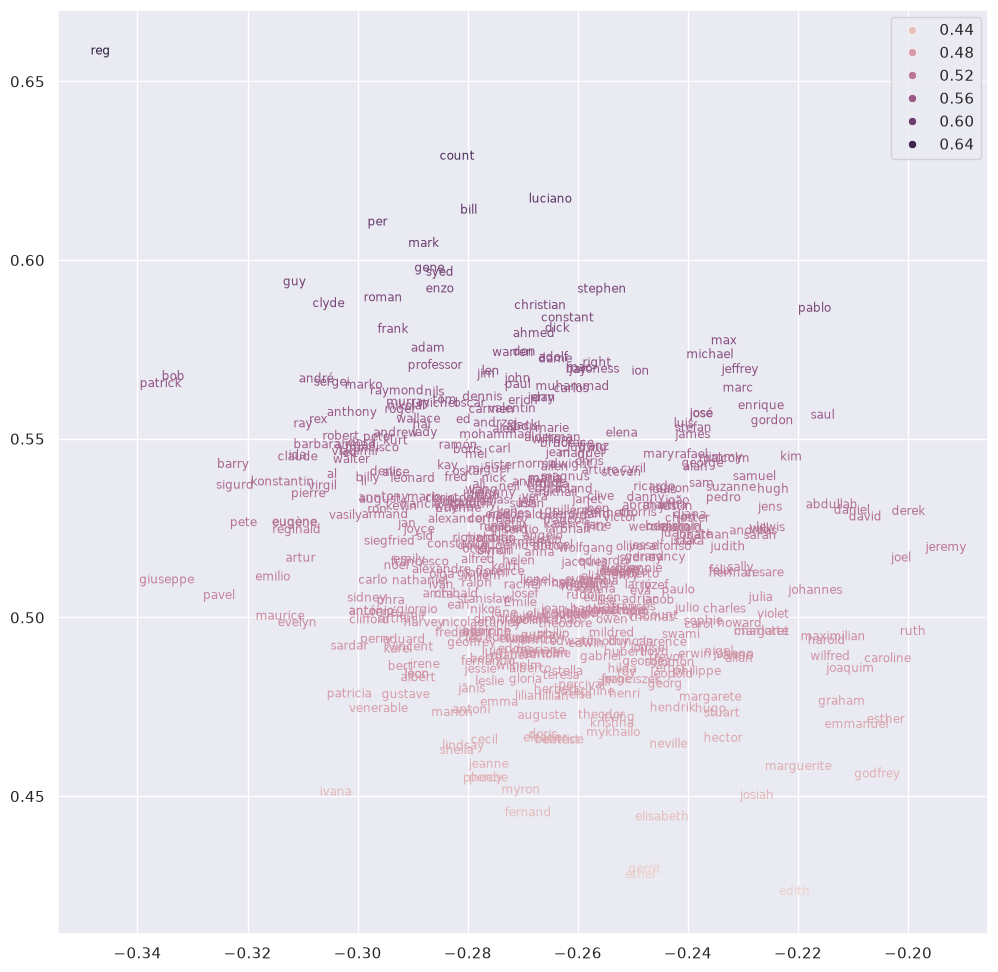

In [ ]:
score = target_sim[:, 5]
dim_reducer.fit(unique_name_embeddings, score)
embed_2d = unique_name_embeddings[:, np.argsort(np.abs(dim_reducer.coef_))[-2:]]

sns.set_theme(rc={'figure.figsize':(12, 12)})
text_scatterplot(x=embed_2d[:, 0], y=dim_reducer.predict(unique_name_embeddings), hue=score, text=selected_names)


<Axes: >

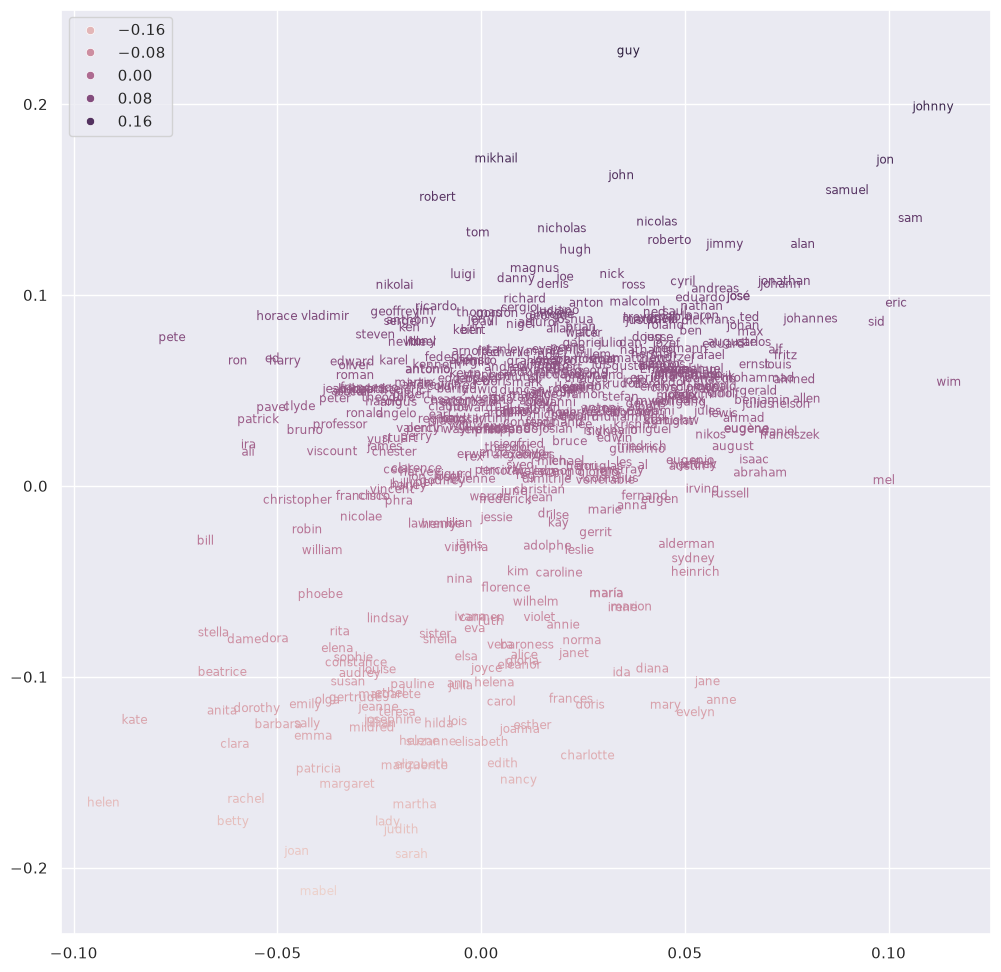

In [ ]:
score = target_sim[:, 0] - target_sim[:, 1]
dim_reducer.fit(unique_name_embeddings, score)
embed_2d = unique_name_embeddings[:, np.argsort(np.abs(dim_reducer.coef_))[-2:]]

sns.set_theme(rc={'figure.figsize':(12, 12)})
text_scatterplot(x=embed_2d[:, 0], y=dim_reducer.predict(unique_name_embeddings), hue=score, text=selected_names)

In [ ]:
name_to_bio_similarity = np.diag(cosine_similarity(embeddings, name_embeddings))
idx = np.argsort(name_to_bio_similarity)
df.iloc[idx]

,id,url,nb_sentences,title,infobox_name,infobox_birth_date,infobox_death_date,infobox_occupation,infobox_nationality,infobox,first_name
56494,163004,https://en.wikipedia.org/wiki/index.php?curid=...,1,rené daumal,rené daumal,1908-03-16,1944-05-21,"para-surrealist writer, poet",french,"{'image': '<none>', 'alt': '<none>', 'caption'...",rené
365062,607150,https://en.wikipedia.org/wiki/index.php?curid=...,2,charles hamilton houston,charles hamilton houston,1895-09-03,1950-04-22,lawyer,united states,"{'image': '<none>', 'image_size': '120px', 'ca...",charles
283802,2472862,https://en.wikipedia.org/wiki/index.php?curid=...,5,ethel l. payne,ethel l. payne,1911-08-14,1991-05-29,journalist,american,"{'image': 'ethel l. payne.jpg', 'alt': '<none>...",ethel
312571,10595787,https://en.wikipedia.org/wiki/index.php?curid=...,5,giangiacomo feltrinelli,giangiacomo feltrinelli,1926-06-19,1972-03-14,"businessman, political activist",italian,"{'image': 'giangiacomo feltrinelli.jpg', 'capt...",giangiacomo
306212,13152517,https://en.wikipedia.org/wiki/index.php?curid=...,1,ned day,ned day,1945-04-05,1987-09-03,journalist,american,"{'image': '<none>', 'alt': '<none>', 'caption'...",ned
...,...,...,...,...,...,...,...,...,...,...,...
31707,315512,https://en.wikipedia.org/wiki/index.php?curid=...,2,itagaki taisuke,itagaki taisuke,1837-05-21,1919-07-16,"politician, cabinet minister",japanese,"{'image': 'itagaki_taisuke_young. jpg', 'image...",itagaki
365761,28013852,https://en.wikipedia.org/wiki/index.php?curid=...,2,alexander d. shimkin,alexander demitri shimkin,1944-10-11,1972-07-12,war correspondent,american,"{'image': 'alexander shimkin 1965.jpg', 'image...",alexander
323968,12548607,https://en.wikipedia.org/wiki/index.php?curid=...,1,fritz hoffmann-la roche,fritz hoffmann-la roche,1868-10-24,1920-04-18,entrepreneur,swiss,"{'image': 'fritzhoffmannalbum1918.jpg', 'alt':...",fritz
28031,26396798,https://en.wikipedia.org/wiki/index.php?curid=...,2,thomas rutherford bacon,thomas rutherford bacon,1850-06-26,1913-03-26,"minister, professor",american,"{'image': '<none> <none>', 'caption': '<none>'...",thomas


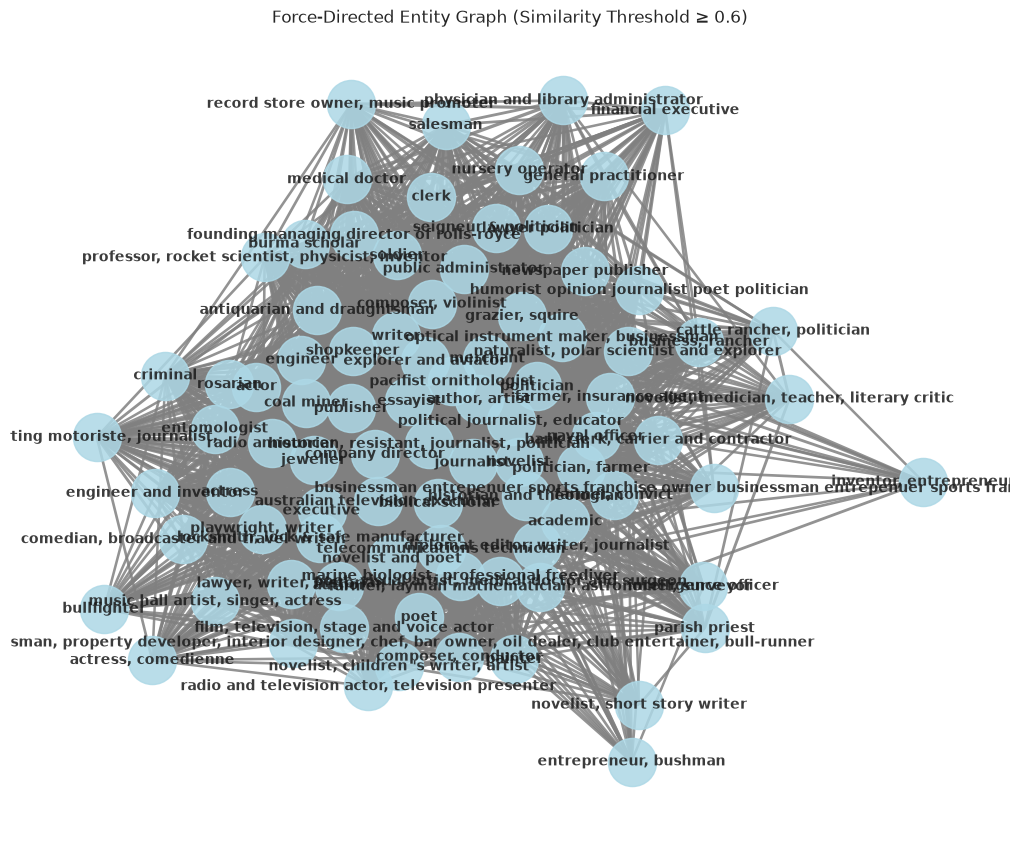

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


def draw_similarity_graph(
    similarity_matrix, names, threshold=0.2, seed=42
):
    """Draws a force-directed graph from a cosine similarity matrix.

    Parameters:
    - similarity_matrix: 2D numpy array or list of lists (n x n)
    - names: list of strings (length n)
    - threshold: float (0.0 to 1.0). Edges with similarity below this are ignored.
    """
    G = nx.Graph()

    # 1. Add nodes
    for name in names:
        G.add_node(name)

    # 2. Add edges (Upper triangle only, ignoring self-similarity on the diagonal)
    n = len(names)
    for i in range(n):
        for j in range(i + 1, n):
            sim = similarity_matrix[i][j]
            if sim >= threshold:
                # In spring_layout, higher 'weight' acts as a stronger spring pulling nodes closer
                G.add_edge(names[i], names[j], weight=sim)

    # 3. Calculate force-directed coordinates (Fruchterman-Reingold)
    pos = nx.spring_layout(G, weight="weight", seed=seed)

    # 4. Render graph
    plt.figure(figsize=(10, 8))

    # Get edge weights to scale their visual thickness
    edge_weights = [G[u][v]["weight"] * 3 for u, v in G.edges()]

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=1200,
        font_size=10,
        font_weight="bold",
        edge_color="gray",
        width=edge_weights,
        alpha=0.85,
    )

    plt.title(f"Force-Directed Entity Graph (Similarity Threshold ≥ {threshold})")
    plt.axis("off")
    plt.show()



draw_similarity_graph(cosine_similarity(embeddings[:100]), df["infobox_occupation"].tolist()[:100], threshold=0.6)

<Axes: >

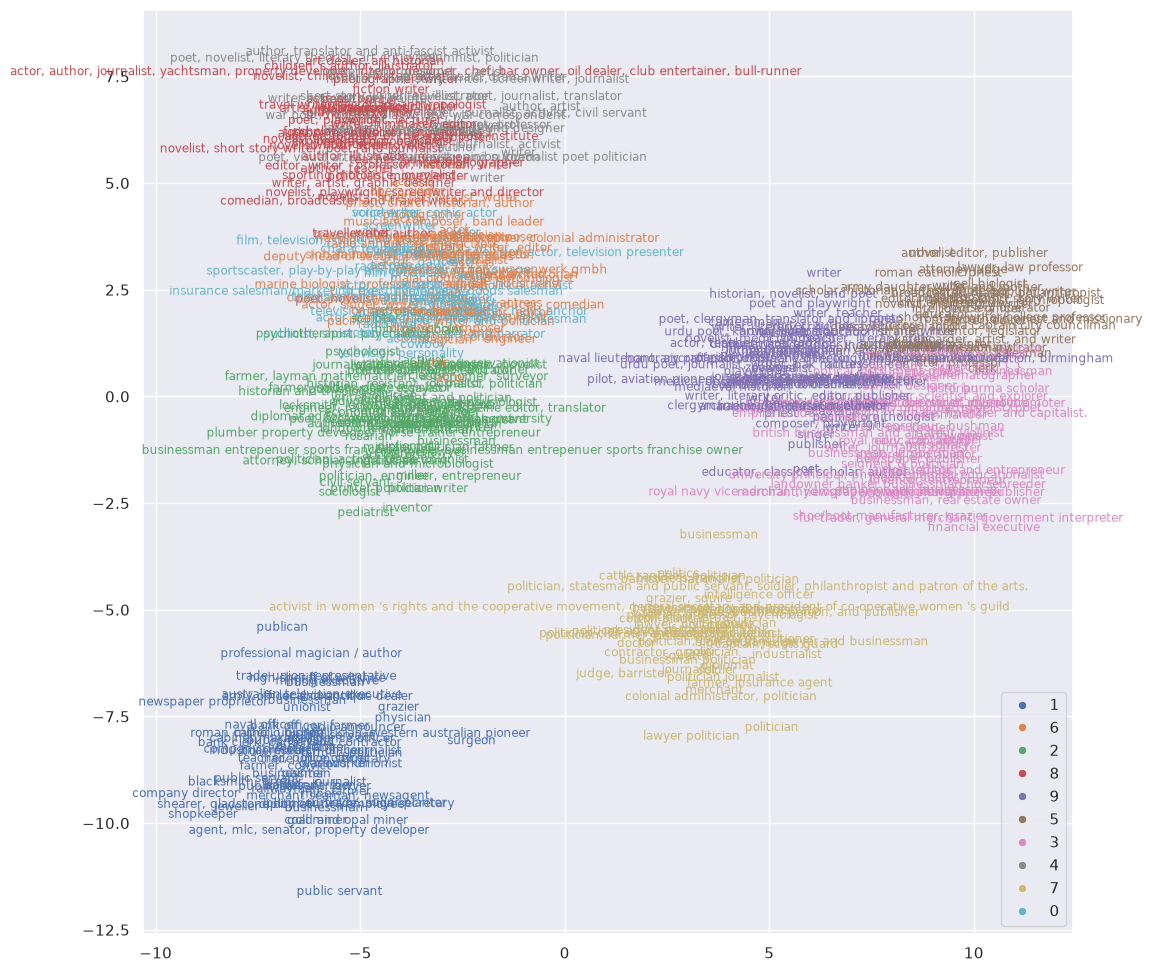

In [ ]:
from sklearn.cluster import KMeans

X = embeddings[:500]
cluster = KMeans(n_clusters=10)
clusters = cluster.fit_predict(X)
lda = LinearDiscriminantAnalysis(n_components=2)
X_2d = lda.fit_transform(X, clusters)
text_scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=[str(x) for x in clusters], text=df["infobox_occupation"].tolist()[:500])

(100, 384)


/home/devin/e/mila_mirror/proj/name-embedding/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


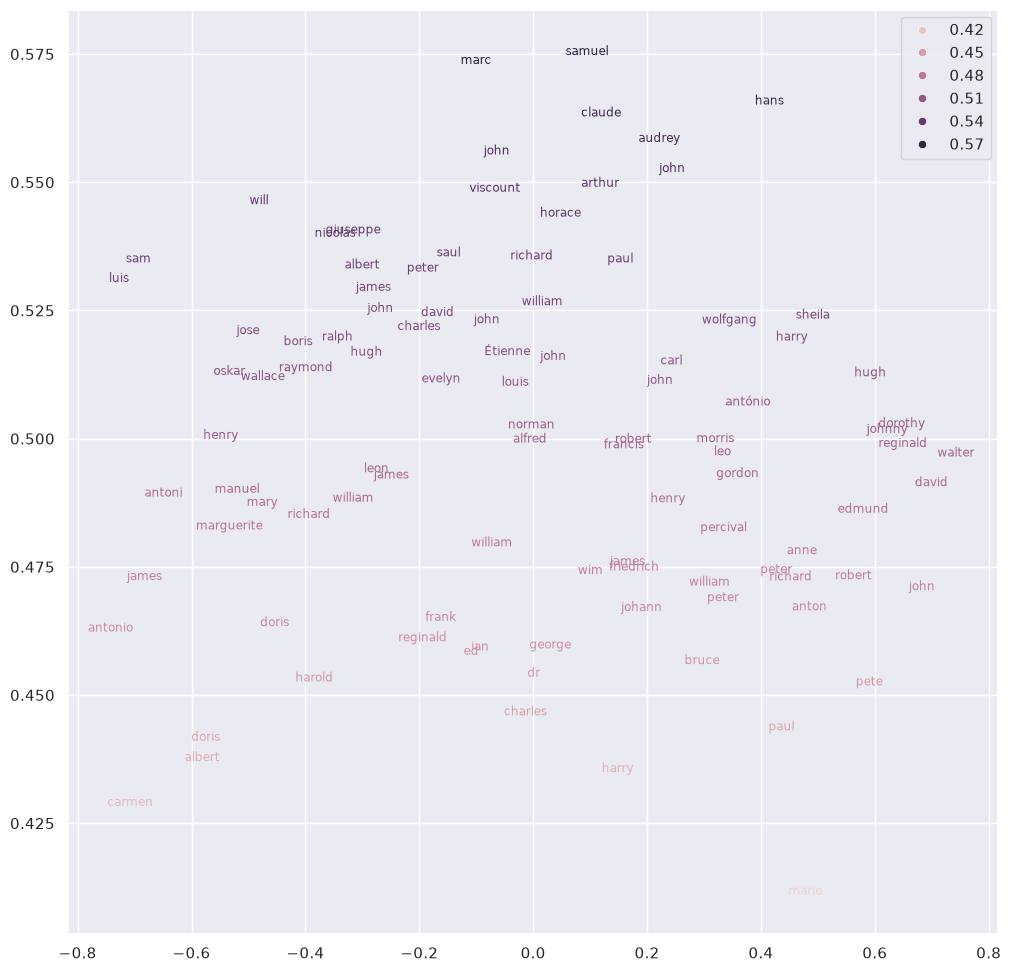

In [ ]:
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

score = target_sim[:, 4]
dim_reducer.fit(unique_name_embeddings, score)

X = embeddings[:100]
print(X.shape)
mds = MDS(n_components=2)
X_2d_mds = mds.fit_transform(X)
# sns.scatterplot(x=X_2d_mds[:, 0], y=X_2d_mds[:, 1], hue=df["infobox_occupation"][:100])
pred = dim_reducer.predict(embeddings)[:100]
text_scatterplot(x=X_2d_mds[:, 0], y=pred, hue=pred, text=df["first_name"].tolist()[:100])
# text_scatterplot(x=X_2d_mds[:, 0], y=pred, hue=pred, text=selected_df["infobox_occupation"].tolist()[:100])
plt.show()

# pca = PCA(n_components=2)
# X_2d_pca = pca.fit_transform(X)
# sns.scatterplot(x=X_2d_pca[:, 0], y=X_2d_pca[:, 1], hue=df["subfamily"])
# plt.show()
# scatterplot(x=X_2d_pca[:, 0], y=X_2d_pca[:, 1], images=images, zoom=0.1)
# plt.show()